# Brazilian E-Commerce Sales & Customer Analytics

## Olist Brazilian E-Commerce Public Dataset

### Objective
To analyze e-commerce sales, customers, products, sellers, payments,
delivery performance, and customer reviews using Python, SQL, Excel, and Power BI.

In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
os.listdir()

['.ipynb_checkpoints',
 '01_olist_data_profiling.ipynb',
 'olist_customers_dataset.csv',
 'Olist_Ecommerce_Analysis (Recovered).xlsx',
 'Olist_Ecommerce_Analysis.xlsx',
 'Olist_Ecommerce_Analytics (recovered).pbix',
 'Olist_Ecommerce_Analytics.pbix',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv',
 'sql']

In [4]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [5]:
print("Customers:", customers.shape)
print("Geolocation:", geolocation.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Category Translation:", category_translation.shape)

Customers: (99441, 5)
Geolocation: (1000163, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [6]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [9]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [10]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [11]:
orders.groupby("order_status")["order_delivered_customer_date"].apply(
    lambda x: x.isna().sum()
)

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_delivered_customer_date, dtype: int64

In [12]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [13]:
reviews[reviews["order_id"].isin(
    orders[
        (orders["order_status"] == "delivered") &
        (orders["order_delivered_customer_date"].isna())
    ]["order_id"]
)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
10690,ee2d30652e2f7fc00861074f795f5bf0,0d3268bad9b086af767785e3f0fc0133,5,Excelente!,O produto chegou muito antes do prazo previsto...,2018-07-06 00:00:00,2018-07-07 18:48:09
24335,bb311d9562ecbefc8e4be756d8999892,e69f75a717d64fc5ecdfae42b2e8e086,5,NaN,NaN,2018-07-07 00:00:00,2018-07-10 11:38:13
27655,c0dd6bec0375c376f044af102118526f,f5dd62b788049ad9fc0526e3ad11a097,5,Entrega super rápida.,"Produto novo, muito bom.",2018-06-29 00:00:00,2018-06-29 16:26:37
51996,4e755f114e50d33b9ac6a56e0d7d3ea9,2d858f451373b04fb5c984a1cc2defaf,5,NaN,NaN,2017-06-25 00:00:00,2017-06-27 01:49:04
56411,25e11638a3d01a87e8e62338a39eee28,2ebdfc4f15f23b91474edf87475f108e,5,NaN,NaN,2018-07-11 00:00:00,2018-07-11 19:27:46
86011,f48c6c944a5d52dcca8ac5c4ec417cf2,2d1e2d5bf4dc7227b3bfebb81328c15f,5,NaN,Chegou rápido tudo ok,2017-12-19 00:00:00,2017-12-19 04:15:39
88893,d055795a562efffefe47ef81e5435322,20edc82cf5400ce95e1afacc25798b31,5,Muito bom,Adorei,2018-07-06 00:00:00,2018-07-06 20:30:17
92001,0d4c56af896dd6eb9de8edbaa1902d22,ab7c89dc1bf4a1ead9d6ec1ec8968a84,1,Péssimo,Comprei um produto de uma marca e recebi outro...,2018-06-16 00:00:00,2018-06-16 13:55:00


In [14]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [15]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [16]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [17]:
customers["customer_id"].nunique()

99441

In [18]:
customers["customer_unique_id"].nunique()

96096

In [19]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [20]:
customer_counts = customers["customer_unique_id"].value_counts()

customer_counts.value_counts().sort_index()

count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [21]:
orders["customer_id"].nunique()

99441

In [22]:
orders["customer_id"].isin(customers["customer_id"]).sum()

np.int64(99441)

In [23]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [24]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [25]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [26]:
order_items["order_id"].isin(orders["order_id"]).sum()

np.int64(112650)

In [27]:
order_items["order_id"].nunique()

98666

In [28]:
orders["order_id"].nunique()

99441

In [29]:
orders_without_items = orders[
    ~orders["order_id"].isin(order_items["order_id"])
]

orders_without_items["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [30]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [31]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [32]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


In [33]:
products[
    products["product_category_name"].isna()
].isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [34]:
products["product_id"].nunique()

32951

In [35]:
products["product_id"].duplicated().sum()

np.int64(0)

In [36]:
order_items["product_id"].isin(products["product_id"]).sum()

np.int64(112650)

In [37]:
sellers.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='str')

In [38]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [39]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 230.3 KB


In [40]:
sellers["seller_id"].nunique()

3095

In [41]:
sellers["seller_id"].duplicated().sum()

np.int64(0)

In [42]:
order_items["seller_id"].isin(sellers["seller_id"]).sum()

np.int64(112650)

In [43]:
order_items["seller_id"].nunique()

3095

In [44]:
payments.shape

(103886, 5)

In [45]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [46]:
payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [47]:
payments["order_id"].nunique()

99440

In [48]:
payments["order_id"].duplicated().sum()

np.int64(4446)

In [49]:
payments["order_id"].isin(orders["order_id"]).sum()

np.int64(103886)

In [50]:
orders_without_payment = orders[
    ~orders["order_id"].isin(payments["order_id"])
]

orders_without_payment

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00


In [51]:
orders_without_payment["order_status"]

30710    delivered
Name: order_status, dtype: str

In [52]:
reviews.shape

(99224, 7)

In [53]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


In [54]:
reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [55]:
reviews["review_id"].nunique()

98410

In [56]:
reviews["review_id"].duplicated().sum()

np.int64(814)

In [57]:
reviews["order_id"].nunique()

98673

In [58]:
reviews["order_id"].isin(orders["order_id"]).sum()

np.int64(99224)

In [59]:
duplicate_reviews = reviews[
    reviews["review_id"].duplicated(keep=False)
].sort_values("review_id")

duplicate_reviews.head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44


In [60]:
duplicate_reviews["review_id"].value_counts().head(10)

review_id
08528f70f579f0c830189efc523d2182    3
0c76e7a547a531e7bf9f0b99cba071c1    3
1fb4ddc969e6bea80e38deec00393a6f    3
2172867fd5b1a55f98fe4608e1547b4b    3
2d6ac45f859465b5c185274a1c929637    3
308316408775d1600dad81bd3184556d    3
32415bbf6e341d5d517080a796f79b5c    3
3415c9f764e478409e8e0660ae816dd2    3
38821b5c496b678cf91acc34892805ad    3
39b4603793c1c7f5f36d809b4a218664    3
Name: count, dtype: int64

In [61]:
id_cols = ["review_id"]

duplicate_reviews.groupby("review_id").agg(
    rows=("review_id", "size"),
    unique_orders=("order_id", "nunique"),
    unique_scores=("review_score", "nunique"),
    unique_comments=("review_comment_message", "nunique"),
    unique_creation_dates=("review_creation_date", "nunique"),
    unique_answer_dates=("review_answer_timestamp", "nunique")
).sort_values("rows", ascending=False).head(10)

,rows,unique_orders,unique_scores,unique_comments,unique_creation_dates,unique_answer_dates
review_id,,,,,,
4548534449b1f572e357211b90724f1b,3,3,1,1,1,1
2d6ac45f859465b5c185274a1c929637,3,3,1,1,1,1
1fb4ddc969e6bea80e38deec00393a6f,3,3,1,0,1,1
4d0e6dd087008d1f992d25ef6e1f619f,3,3,1,0,1,1
c444278834184f72b1484dfe47de7f97,3,3,1,0,1,1
f4bb9d6dd4fb6dcc2298f0e7b17b8e1e,3,3,1,0,1,1
e44840754f12fad2b8646712121b349a,3,3,1,0,1,1
0c76e7a547a531e7bf9f0b99cba071c1,3,3,1,0,1,1
69a1068c3128a14994e3e422e4539e04,3,3,1,0,1,1


In [62]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [63]:
reviews["review_score"].value_counts(normalize=True).sort_index() * 100

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64

In [64]:
geolocation.shape

(1000163, 5)

In [65]:
geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 50.1 MB


In [66]:
geolocation.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [67]:
geolocation["geolocation_zip_code_prefix"].nunique()

19015

In [68]:
geolocation["geolocation_zip_code_prefix"].duplicated().sum()

np.int64(981148)

In [69]:
geolocation["geolocation_zip_code_prefix"].value_counts().head(10)

geolocation_zip_code_prefix
24220    1146
24230    1102
38400     965
35500     907
11680     879
22631     832
30140     810
11740     788
38408     773
28970     743
Name: count, dtype: int64

In [70]:
geolocation.duplicated().sum()

np.int64(261831)

In [71]:
category_translation.shape

(71, 2)

In [72]:
category_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB


In [73]:
category_translation.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [74]:
category_translation["product_category_name"].nunique()

71

In [75]:
category_translation["product_category_name"].duplicated().sum()

np.int64(0)

In [76]:
products["product_category_name"].isin(
    category_translation["product_category_name"]
).sum()

np.int64(32328)

# 3. Data Quality Assessment

## 3.1 Summary of Identified Data Quality Issues

The raw Olist datasets were profiled to identify missing values, duplicate records,
referential integrity issues, and structural characteristics. The identified issues
will be assessed before creating analysis-ready datasets.

In [77]:
products[
    products[
        ["product_weight_g",
         "product_length_cm",
         "product_height_cm",
         "product_width_cm"]
    ].isna().any(axis=1)
]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
id="5v7k2m"
products_with_missing_physical = products[
    products[
        ["product_weight_g",
         "product_length_cm",
         "product_height_cm",
         "product_width_cm"]
    ].isna().any(axis=1)
]

products_with_missing_physical["product_id"].isin(
    order_items["product_id"]
)

8578     True
18851    True
Name: product_id, dtype: bool

In [79]:
missing_category_products = products[
    products["product_category_name"].isna()
]

missing_category_products["product_id"].isin(
    order_items["product_id"]
).sum()

np.int64(610)

In [80]:
untranslated_categories = products.loc[
    products["product_category_name"].notna() &
    ~products["product_category_name"].isin(
        category_translation["product_category_name"]
    ),
    "product_category_name"
].unique()

untranslated_categories

<ArrowStringArray>
['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
Length: 2, dtype: str

In [81]:
products[
    products["product_category_name"].isin(untranslated_categories)
]["product_category_name"].value_counts()

product_category_name
portateis_cozinha_e_preparadores_de_alimentos    10
pc_gamer                                          3
Name: count, dtype: int64

In [82]:
orders[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].apply(pd.to_datetime, errors="coerce").isna().sum()

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [83]:
order_dates = orders[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].apply(pd.to_datetime, errors="coerce")

print("Approved before purchase:",
      (order_dates["order_approved_at"] <
       order_dates["order_purchase_timestamp"]).sum())

print("Carrier before purchase:",
      (order_dates["order_delivered_carrier_date"] <
       order_dates["order_purchase_timestamp"]).sum())

print("Customer delivery before purchase:",
      (order_dates["order_delivered_customer_date"] <
       order_dates["order_purchase_timestamp"]).sum())

print("Customer delivery before carrier:",
      (order_dates["order_delivered_customer_date"] <
       order_dates["order_delivered_carrier_date"]).sum())

Approved before purchase: 0
Carrier before purchase: 166
Customer delivery before purchase: 0
Customer delivery before carrier: 23


In [84]:
carrier_before_purchase = orders[
    pd.to_datetime(orders["order_delivered_carrier_date"], errors="coerce")
    <
    pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
]

carrier_before_purchase[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].head(20)

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date
615,b9afddbdcfadc9a87b41a83271c3e888,delivered,2018-08-16 13:50:48,2018-08-16 13:27:00,2018-08-24 14:58:37
1111,ad133696906f6a78826daa0911b7daec,delivered,2018-06-15 15:41:22,2018-06-15 14:52:00,2018-06-22 18:09:37
1329,74e033208dc13a7b8127eb8e73d09b76,delivered,2018-05-02 10:48:44,2018-05-02 09:49:00,2018-05-07 23:06:36
1372,a6b58794fd2ba533359a76c08df576e3,delivered,2018-05-14 15:18:23,2018-05-14 13:46:00,2018-05-19 19:33:32
1864,5792e0b1c8c8a2bf53af468c9a422c88,delivered,2018-07-26 13:25:14,2018-07-26 12:42:00,2018-07-30 14:45:02
2760,c3eb293fd154223498b6551a728203e8,delivered,2018-07-19 14:06:04,2018-07-19 13:49:00,2018-07-24 19:35:36
3473,b0c2a7d04b165525254254a728c50a4e,delivered,2018-06-07 13:28:30,2018-06-07 13:22:00,2018-06-21 17:36:43
3661,2033a4586b5bec3229ebc1675a8ae092,delivered,2018-06-12 10:10:25,2018-06-12 10:09:00,2018-06-19 14:08:27
4114,08adcddad19d3acf37d1fa01cb9ded1e,delivered,2018-06-27 11:16:44,2018-06-27 10:57:00,2018-06-29 17:39:53
4159,dee6298ce7d1fb2645141ef9972157aa,shipped,2018-04-30 14:06:12,2018-04-30 12:59:00,NaN


In [85]:
carrier_before_purchase["order_status"].value_counts()

order_status
delivered    165
shipped        1
Name: count, dtype: int64

In [86]:
carrier_before_purchase["time_difference_hours"] = (
    pd.to_datetime(carrier_before_purchase["order_delivered_carrier_date"])
    - pd.to_datetime(carrier_before_purchase["order_purchase_timestamp"])
).dt.total_seconds() / 3600

carrier_before_purchase["time_difference_hours"].describe()

count     166.000000
mean      -26.039478
std       318.923845
min     -4109.098056
25%        -1.017500
50%        -0.599861
75%        -0.234444
max        -0.006667
Name: time_difference_hours, dtype: float64

In [87]:
carrier_before_purchase[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_carrier_date",
        "time_difference_hours"
    ]
].sort_values("time_difference_hours").head(20)

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,time_difference_hours
25883,7c48bb55e8e4f7e56d412e9653db37bc,delivered,2018-07-16 18:40:53,2018-01-26 13:35:00,-4109.098056
83321,4021cd7611d6d9ce5ffcd24817fc374f,delivered,2018-08-18 11:49:40,2018-08-14 06:22:00,-101.461111
67844,db090a16182b263b1e896bb26c6f66cf,delivered,2018-07-13 16:14:08,2018-07-13 13:59:00,-2.252222
65452,9711d975b961355b4b5d636857e48498,delivered,2018-06-13 15:23:50,2018-06-13 13:15:00,-2.147222
79401,89d32b64af005178b318f76cd60f2c3c,delivered,2018-07-06 11:54:40,2018-07-06 09:48:00,-2.111111
13969,6192897f85cb2aff6dd1fca56fddb45e,delivered,2018-07-18 13:34:22,2018-07-18 11:33:00,-2.022778
43657,3ed559dec69ab96d9074fedaf18650eb,delivered,2018-06-15 13:20:09,2018-06-15 11:22:00,-1.969167
4256,4e157a36ea9cf89bde6fff57a780b525,delivered,2018-08-24 14:37:50,2018-08-24 12:43:00,-1.913889
74503,119060af27b04f5fae8b2b0e27eef7f9,delivered,2018-06-11 14:34:47,2018-06-11 12:45:00,-1.829722
21910,e23c9dcc304042fa90d538be679fa68d,delivered,2018-06-13 11:41:23,2018-06-13 09:53:00,-1.806389


In [88]:
customer_before_carrier = orders[
    pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
    <
    pd.to_datetime(orders["order_delivered_carrier_date"], errors="coerce")
]

customer_before_carrier[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].sort_values("order_delivered_customer_date").head(20)

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date
49933,76458889992169d3135b264dc13aec67,delivered,2016-10-07 10:05:16,2016-10-26 11:43:06,2016-10-20 18:03:17
71227,19feb5627c41ea1b36a8e50a469b3644,delivered,2016-10-07 17:09:56,2016-10-26 11:42:05,2016-10-20 19:07:54
95634,f688669f48063536e082bb32d634cd46,delivered,2016-10-07 10:28:56,2016-10-21 18:02:40,2016-10-20 20:33:27
21338,8c78d01de3a9009e23d6877a7cc9be20,delivered,2016-10-08 15:36:50,2016-10-26 11:41:53,2016-10-25 17:51:46
74967,d5558a097766363b8e76b38c43332e8a,delivered,2017-02-04 19:01:33,2017-02-15 08:55:26,2017-02-10 07:58:32
34939,c1e2bf2b7dd3309f2f5356c6b63968fa,delivered,2017-02-10 10:19:10,2017-03-02 17:34:26,2017-02-14 15:15:57
41636,b866af202be0692766081310cd4085e1,delivered,2017-01-27 14:59:17,2017-02-20 02:32:08,2017-02-15 03:53:46
76120,771c4f1f521f462e4b95619e648aaeab,delivered,2017-03-22 20:15:15,2017-03-30 13:14:34,2017-03-28 17:28:32
45302,29941903985f944b0ffc49c479c1547d,delivered,2017-05-29 16:16:50,2017-06-09 15:07:29,2017-06-02 11:09:16
22520,b27af682321527a6349f1761eb3f360c,delivered,2017-06-14 20:17:04,2017-06-27 14:51:54,2017-06-26 15:45:35


## 3.1 Identified Data Quality Issues

The raw Olist datasets were systematically assessed for missing values, duplicate records, referential integrity, and logical consistency. The identified issues and their proposed treatments are summarized below.

| Dataset              | Data Quality Issue                                |      Affected Records | Treatment                                                                                                       |
| -------------------- | ------------------------------------------------- | --------------------: | --------------------------------------------------------------------------------------------------------------- |
| Orders               | Missing `order_approved_at`                       |                   160 | Retain; do not impute. Exclude only from analyses requiring approval time.                                      |
| Orders               | Missing `order_delivered_carrier_date`            |                 1,783 | Retain; exclude from calculations requiring carrier handover time.                                              |
| Orders               | Missing `order_delivered_customer_date`           |                 2,965 | Retain; exclude from actual delivery-time calculations.                                                         |
| Orders               | Delivered orders missing customer-delivery date   |                     8 | Retain; exclude from delivery-duration calculations.                                                            |
| Orders               | Carrier date earlier than purchase date           |                   166 | Retain raw records; exclude from duration calculations when chronological validity is violated.                 |
| Orders               | Customer delivery earlier than carrier date       |                    23 | Retain raw records; exclude from calculations requiring a valid carrier-to-customer sequence.                   |
| Order Items          | Orders without item records                       |                   775 | Retain orders; investigate by order status. Exclude from item-level sales analysis where no item record exists. |
| Payments             | Order without payment record                      |                     1 | Retain order; exclude from payment-dependent analysis.                                                          |
| Reviews              | Missing review titles                             |                87,656 | Retain; treat as optional text.                                                                                 |
| Reviews              | Missing review messages                           |                58,247 | Retain; use only available text for text/sentiment analysis.                                                    |
| Reviews              | Non-unique `review_id`                            |  814 repeated records | Do not remove blindly; use the appropriate analysis grain, such as `order_id`, when required.                   |
| Products             | Missing product categories                        |                   610 | Retain; assign an explicit missing/unknown category in derived analysis data when required.                     |
| Products             | Missing physical attributes                       |                     2 | Retain; exclude only from analyses requiring the missing physical attributes.                                   |
| Products             | Products with missing categories appear in orders |                   610 | Retain because they represent actual transaction records.                                                       |
| Category Translation | Product records without English translation       |                    13 | Retain original category; do not delete due to missing translation.                                             |
| Category Translation | Untranslated category names                       |                     2 | Retain original Portuguese category names or use verified translations later.                                   |
| Geolocation          | Repeated ZIP-code prefixes                        | 981,148 repeated rows | Expected structure; do not treat as ordinary duplicates.                                                        |
| Geolocation          | Exact duplicate rows                              |               261,831 | Retain raw data; remove/aggregate only when creating an analysis-specific geographic lookup.                    |

## 3.2 Data Quality Treatment Principles

The raw CSV files will not be modified. Missing values will not be automatically replaced with zero, mean values, or estimated dates because such replacements could introduce artificial information.

Records will be excluded only from analyses where the missing or inconsistent value is required for the calculation. For example, orders without valid delivery timestamps will be excluded from delivery-duration calculations but retained for other order-level analyses.

Duplicate records will be investigated according to the structure and business meaning of each dataset rather than being removed automatically.

All derived cleaning and transformation steps will be performed on separate analysis-ready datasets, preserving the original raw data for reference and reproducibility.


# 4. Data Cleaning & Transformation

The raw datasets are preserved unchanged. Separate copies are created for
cleaning and transformation so that the original data remains available
for validation and reproducibility.

In [89]:
customers_clean = customers.copy()
orders_clean = orders.copy()
order_items_clean = order_items.copy()
payments_clean = payments.copy()
reviews_clean = reviews.copy()
products_clean = products.copy()
sellers_clean = sellers.copy()
geolocation_clean = geolocation.copy()
category_translation_clean = category_translation.copy()

In [90]:
orders_clean.shape

(99441, 8)

In [91]:
products_clean.shape

(32951, 9)

## 4.1 Convert Date Columns to Datetime

The date fields in the orders dataset are initially stored as strings. They are
converted to datetime format to support chronological comparisons and time-based
analysis.

In [92]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

In [93]:
orders_clean[order_date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## 4.2 Convert Date Columns in Order Items

The `shipping_limit_date` field is converted from string format to datetime
format so that shipping-related time analysis can be performed.

In [94]:
order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"]
)

In [95]:
order_items_clean["shipping_limit_date"].dtype

dtype('<M8[us]')

## 4.3 Convert Review Dates to Datetime

The review creation and answer timestamps are converted from string format to
datetime format to support time-based customer satisfaction analysis.

In [96]:
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_columns:
    reviews_clean[col] = pd.to_datetime(reviews_clean[col])

In [97]:
reviews_clean[review_date_columns].dtypes

review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [98]:
orders_clean[order_date_columns].isna().sum()
order_items_clean["shipping_limit_date"].isna().sum()
reviews_clean[review_date_columns].isna().sum()

review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [99]:
orders_clean[order_date_columns].isna().sum()

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [100]:
order_items_clean["shipping_limit_date"].isna().sum()

np.int64(0)

In [101]:
categorical_columns = {
    "orders": ["order_status"],
    "products": ["product_category_name"],
    "customers": ["customer_city", "customer_state"],
    "sellers": ["seller_city", "seller_state"],
    "payments": ["payment_type"],
    "category_translation": [
        "product_category_name",
        "product_category_name_english"
    ]
}

for table_name, columns in categorical_columns.items():
    print(f"\n--- {table_name} ---")
    for col in columns:
        df = globals()[f"{table_name}_clean"]
        leading_trailing_spaces = (
            df[col].notna() &
            (df[col] != df[col].str.strip())
        ).sum()
        print(f"{col}: {leading_trailing_spaces}")


--- orders ---
order_status: 0

--- products ---
product_category_name: 0

--- customers ---
customer_city: 0
customer_state: 0

--- sellers ---
seller_city: 0
seller_state: 0

--- payments ---
payment_type: 0

--- category_translation ---
product_category_name: 0
product_category_name_english: 0


In [102]:
products_clean["product_category_name_original"] = (
    products_clean["product_category_name"]
)

In [103]:
products_clean["product_category_name_analysis"] = (
    products_clean["product_category_name"]
    .fillna("Unknown")
)

In [104]:
products_clean[
    [
        "product_category_name",
        "product_category_name_original",
        "product_category_name_analysis"
    ]
].head()

,product_category_name,product_category_name_original,product_category_name_analysis
0,perfumaria,perfumaria,perfumaria
1,artes,artes,artes
2,esporte_lazer,esporte_lazer,esporte_lazer
3,bebes,bebes,bebes
4,utilidades_domesticas,utilidades_domesticas,utilidades_domesticas


In [105]:
products_clean["product_category_name_analysis"].value_counts().head()

product_category_name_analysis
cama_mesa_banho          3029
esporte_lazer            2867
moveis_decoracao         2657
beleza_saude             2444
utilidades_domesticas    2335
Name: count, dtype: int64

In [106]:
products_clean.drop(
    columns=["product_category_name_original"],
    inplace=True
)

In [107]:
products_clean.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_analysis'],
      dtype='str')

In [108]:
category_map = dict(
    zip(
        category_translation_clean["product_category_name"],
        category_translation_clean["product_category_name_english"]
    )
)

In [109]:
products_clean["product_category_name_english"] = (
    products_clean["product_category_name"]
    .map(category_map)
)

In [110]:
products_clean[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head(10)

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [111]:
products_clean["product_category_name_english"].isna().sum()

np.int64(623)

In [112]:
products_clean["product_category_analysis"] = (
    products_clean["product_category_name_english"]
    .fillna(products_clean["product_category_name"])
    .fillna("Unknown")
)

In [113]:
products_clean["product_category_analysis"].isna().sum()

np.int64(0)

In [114]:
products_clean["product_category_analysis"].value_counts().tail(10)

product_category_analysis
diapers_and_hygiene                              12
la_cuisine                                       10
portateis_cozinha_e_preparadores_de_alimentos    10
furniture_mattress_and_upholstery                10
tablets_printing_image                            9
fashion_childrens_clothes                         5
home_comfort_2                                    5
pc_gamer                                          3
security_and_services                             2
cds_dvds_musicals                                 1
Name: count, dtype: int64

In [115]:
physical_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

products_clean[physical_columns].isna().sum()

product_weight_g     2
product_length_cm    2
product_height_cm    2
product_width_cm     2
dtype: int64

In [116]:
products_clean[
    products_clean[physical_columns].isna().any(axis=1)
][
    ["product_id", "product_category_analysis"] + physical_columns
]

,product_id,product_category_analysis,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,baby,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,Unknown,NaN,NaN,NaN,NaN


In [117]:
customers_clean["customer_id"].duplicated().sum()

np.int64(0)

In [118]:
customers_clean["customer_unique_id"].duplicated().sum()

np.int64(3345)

In [119]:
customer_frequency = customers_clean["customer_unique_id"].value_counts()

(customer_frequency > 1).sum()

np.int64(2997)

In [120]:
customer_frequency[customer_frequency > 1].head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dc813062e0fc23409cd255f7f53c7074     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
de34b16117594161a6a89c50b289d35a     6
Name: count, dtype: int64

In [121]:
orders_clean["order_id"].duplicated().sum()

np.int64(0)

In [122]:
orders_clean["customer_id"].duplicated().sum()

np.int64(0)

In [123]:
order_items_clean["order_item_id"].duplicated().sum()

np.int64(112629)

In [124]:
order_items_clean[["order_id", "order_item_id"]].duplicated().sum()

np.int64(0)

In [125]:
order_items_clean["order_id"].duplicated().sum()

np.int64(13984)

In [126]:
payments_clean["order_id"].duplicated().sum()

np.int64(4446)

In [127]:
payments_clean[["order_id", "payment_sequential"]].duplicated().sum()

np.int64(0)

In [128]:
payments_clean["payment_sequential"].duplicated().sum()

np.int64(103857)

In [129]:
reviews_clean["review_id"].duplicated().sum()

np.int64(814)

In [130]:
reviews_clean[["review_id", "order_id"]].duplicated().sum()

np.int64(0)

In [131]:
reviews_clean["order_id"].duplicated().sum()

np.int64(551)

In [132]:
products_clean["product_id"].duplicated().sum()

np.int64(0)

In [133]:
products_clean["product_category_analysis"].duplicated().sum()

np.int64(32877)

In [134]:
sellers_clean["seller_id"].duplicated().sum()

np.int64(0)

In [135]:
order_items_clean["seller_id"].isin(
    sellers_clean["seller_id"]
).all()

np.True_

In [136]:
category_translation_clean["product_category_name"].duplicated().sum()

np.int64(0)

In [137]:
category_translation_clean["product_category_name_english"].duplicated().sum()

np.int64(0)

In [138]:
products_clean["product_category_name"].dropna().isin(
    category_translation_clean["product_category_name"]
).mean()

np.float64(0.9995980334559846)

In [139]:
id="geo01"
geolocation_clean.groupby(
    "geolocation_zip_code_prefix"
).agg(
    rows=("geolocation_zip_code_prefix", "size"),
    unique_lat=("geolocation_lat", "nunique"),
    unique_lng=("geolocation_lng", "nunique")
).sort_values(
    "rows", ascending=False
).head(10)

,rows,unique_lat,unique_lng
geolocation_zip_code_prefix,,,
24220,1146,410,411
24230,1102,327,327
38400,965,746,745
35500,907,726,726
11680,879,726,726
22631,832,141,142
30140,810,379,380
11740,788,666,666
38408,773,600,599


In [140]:
geolocation_clean.duplicated().sum()

np.int64(261831)

In [141]:
orders_clean.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [142]:
orders_clean.loc[
    orders_clean["order_approved_at"].isna(),
    "order_status"
].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [143]:
orders_clean.loc[
    orders_clean["order_delivered_carrier_date"].isna(),
    "order_status"
].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [144]:
orders_clean.loc[
    orders_clean["order_delivered_customer_date"].isna(),
    "order_status"
].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [145]:
order_items_clean.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [146]:
payments_clean.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [147]:
reviews_clean.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [148]:
products_clean.isna().sum()

product_id                          0
product_category_name             610
product_name_lenght               610
product_description_lenght        610
product_photos_qty                610
product_weight_g                    2
product_length_cm                   2
product_height_cm                   2
product_width_cm                    2
product_category_name_analysis      0
product_category_name_english     623
product_category_analysis           0
dtype: int64

In [149]:
customers_clean.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [150]:
sellers_clean.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [151]:
geolocation_clean.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [152]:
category_translation_clean.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

## 4.17 Missing Value Treatment

Missing values were assessed according to their business meaning rather than being automatically imputed. Date-related missing values in the orders table were retained because they represent genuine stages of the order lifecycle (e.g., cancelled, processing, shipped, or unavailable orders). These records will only be excluded from analyses that require the corresponding timestamps.

In the products table, 610 products had missing category names and two products had missing physical measurements. Instead of deleting these products, a complete analytical category field (`product_category_analysis`) was created, while physical measurements remained missing to avoid introducing artificial values. Review titles and review messages were also retained as missing because they are optional textual fields, whereas review scores remain complete.

No missing values were identified in the customers, sellers, payments, geolocation, or category translation tables.


In [153]:
orders_clean["purchase_year"] = (
    orders_clean["order_purchase_timestamp"].dt.year
)

orders_clean["purchase_month"] = (
    orders_clean["order_purchase_timestamp"].dt.month
)

orders_clean["purchase_month_name"] = (
    orders_clean["order_purchase_timestamp"].dt.month_name()
)

orders_clean["purchase_day"] = (
    orders_clean["order_purchase_timestamp"].dt.day
)

orders_clean["purchase_day_of_week"] = (
    orders_clean["order_purchase_timestamp"].dt.day_name()
)

In [154]:
orders_clean[
    [
        "order_purchase_timestamp",
        "purchase_year",
        "purchase_month",
        "purchase_month_name",
        "purchase_day",
        "purchase_day_of_week"
    ]
].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_month_name,purchase_day,purchase_day_of_week
0,2017-10-02 10:56:33,2017,10,October,2,Monday
1,2018-07-24 20:41:37,2018,7,July,24,Tuesday
2,2018-08-08 08:38:49,2018,8,August,8,Wednesday
3,2017-11-18 19:28:06,2017,11,November,18,Saturday
4,2018-02-13 21:18:39,2018,2,February,13,Tuesday


In [155]:
orders_clean["valid_delivery_sequence"] = (
    orders_clean["order_purchase_timestamp"].notna()
    & orders_clean["order_delivered_carrier_date"].notna()
    & orders_clean["order_delivered_customer_date"].notna()
    & (
        orders_clean["order_delivered_carrier_date"]
        >= orders_clean["order_purchase_timestamp"]
    )
    & (
        orders_clean["order_delivered_customer_date"]
        >= orders_clean["order_delivered_carrier_date"]
    )
)

In [156]:
orders_clean["valid_delivery_sequence"].value_counts()

valid_delivery_sequence
True     96287
False     3154
Name: count, dtype: int64

In [157]:
orders_clean["delivery_days"] = np.where(
    orders_clean["valid_delivery_sequence"],
    (
        orders_clean["order_delivered_customer_date"]
        - orders_clean["order_purchase_timestamp"]
    ).dt.total_seconds() / (24 * 60 * 60),
    np.nan
)

In [158]:
orders_clean["delivery_days"].describe()

count    96287.000000
mean        12.568586
std          9.549954
min          0.533414
25%          6.776076
50%         10.227199
75%         15.732668
max        209.628611
Name: delivery_days, dtype: float64

In [159]:
orders_clean["delivery_days"].isna().sum()

np.int64(3154)

In [160]:
orders_clean["estimated_delivery_days"] = (
    orders_clean["order_estimated_delivery_date"]
    - orders_clean["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [161]:
orders_clean["estimated_delivery_days"].describe()

count    99441.000000
mean        23.767650
std          8.832371
min          1.648993
25%         18.331690
50%         23.240370
75%         28.424861
max        155.135463
Name: estimated_delivery_days, dtype: float64

In [162]:
orders_clean["delivery_delay_days"] = np.where(
    orders_clean["valid_delivery_sequence"],
    orders_clean["delivery_days"]
    - orders_clean["estimated_delivery_days"],
    np.nan
)

In [163]:
orders_clean["delivery_delay_days"].describe()

count    96287.000000
mean       -11.170165
std         10.185275
min       -146.016123
25%        -16.241539
50%        -11.929676
75%         -6.387182
max        188.975081
Name: delivery_delay_days, dtype: float64

In [164]:
orders_clean["delivery_delay_days"].isna().sum()

np.int64(3154)

In [165]:
orders_clean.loc[
    orders_clean["delivery_delay_days"].abs().nlargest(10).index,
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "estimated_delivery_days",
        "delivery_delay_days"
    ]
].sort_values("delivery_delay_days")

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_delivery_days,delivery_delay_days
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,188.134618,28.524687,159.609931
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,194.049583,32.439618,161.609965
40847,d24e8541128cea179a11a65176e0a96f,delivered,2017-06-12 13:14:11,2017-06-16 14:44:37,2017-12-04 18:36:29,2017-06-26,175.223819,13.448484,161.775336
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-03-21 14:50:25,2017-09-19 17:14:25,2017-04-10,187.743843,25.025498,162.718345
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-03-15 13:00:08,2017-09-19 15:12:50,2017-04-07,195.634016,30.000104,165.633912
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,2017-04-06,194.633611,28.050231,166.583380
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,2017-04-05,189.863160,22.154745,167.708414
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,191.463542,15.594433,175.869109
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,209.628611,28.019826,181.608785
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-02-26 18:49:07,2018-09-19 23:24:07,2018-03-15,208.351759,19.376678,188.975081


In [166]:
orders_clean["delivery_delay_days"].gt(30).sum()

np.int64(360)

In [167]:
orders_clean["delivery_delay_days"].gt(60).sum()

np.int64(84)

In [168]:
orders_clean["delivery_delay_days"].gt(90).sum()

np.int64(47)

In [169]:
orders_clean["is_delayed"] = np.where(
    orders_clean["valid_delivery_sequence"],
    orders_clean["delivery_delay_days"] > 0,
    np.nan
)

In [170]:
orders_clean["is_delayed"].value_counts(dropna=False)

is_delayed
0.0    88464
1.0     7823
NaN     3154
Name: count, dtype: int64

In [171]:
orders_clean["delivery_status"] = np.select(
    [
        orders_clean["is_delayed"] == 1,
        orders_clean["is_delayed"] == 0
    ],
    [
        "Delayed",
        "On Time / Early"
    ],
    default="Unknown"
)

In [172]:
orders_clean["delivery_status"].value_counts()

delivery_status
On Time / Early    88464
Delayed             7823
Unknown             3154
Name: count, dtype: int64

In [173]:
order_value_summary = (
    order_items_clean
    .groupby("order_id")
    .agg(
        product_sales=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count")
    )
    .reset_index()
)

In [174]:
order_value_summary["total_order_value"] = (
    order_value_summary["product_sales"]
    + order_value_summary["freight_value"]
)

In [175]:
order_value_summary.head()

,order_id,product_sales,freight_value,item_count,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,218.04


In [176]:
order_value_summary["order_id"].duplicated().sum()

np.int64(0)

In [177]:
order_value_summary.shape

(98666, 5)

In [178]:
order_value_summary["order_id"].isin(
    orders_clean["order_id"]
).mean()

np.float64(1.0)

In [179]:
orders_clean = orders_clean.merge(
    order_value_summary[
        [
            "order_id",
            "product_sales",
            "freight_value",
            "item_count",
            "total_order_value"
        ]
    ],
    on="order_id",
    how="left"
)

In [180]:
orders_clean.shape

(99441, 23)

In [181]:
orders_clean[
    ["product_sales", "freight_value", "item_count", "total_order_value"]
].isna().sum()

product_sales        775
freight_value        775
item_count           775
total_order_value    775
dtype: int64

In [182]:
orders_clean[
    ["product_sales", "freight_value", "item_count", "total_order_value"]
].describe()

,product_sales,freight_value,item_count,total_order_value
count,98666.000000,98666.000000,98666.000000,98666.000000
mean,137.754076,22.823562,1.141731,160.577638
std,210.645145,21.650909,0.538452,220.466087
min,0.850000,0.000000,1.000000,9.590000
25%,45.900000,13.850000,1.000000,61.980000
50%,86.900000,17.170000,1.000000,105.290000
75%,149.900000,24.040000,1.000000,176.870000
max,13440.000000,1794.960000,21.000000,13664.080000


In [183]:
orders_clean = orders_clean.merge(
    customers_clean[
        ["customer_id", "customer_unique_id"]
    ],
    on="customer_id",
    how="left"
)

In [184]:
orders_clean["customer_unique_id"].isna().sum()

np.int64(0)

In [185]:
orders_clean.shape

(99441, 24)

In [186]:
customer_order_frequency = (
    orders_clean
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

In [187]:
orders_clean["is_repeat_customer"] = (
    orders_clean["customer_unique_id"]
    .map(customer_order_frequency)
    .gt(1)
)

In [188]:
orders_clean["is_repeat_customer"].value_counts()

is_repeat_customer
False    93099
True      6342
Name: count, dtype: int64

In [189]:
customer_order_frequency.describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_id, dtype: float64

In [190]:
(customer_order_frequency > 1).sum()

np.int64(2997)

In [191]:
customer_order_frequency.size

96096

In [192]:
orders_clean["customer_order_count"] = (
    orders_clean["customer_unique_id"]
    .map(customer_order_frequency)
)

In [193]:
orders_clean[
    ["customer_unique_id", "customer_order_count", "is_repeat_customer"]
].head(10)

,customer_unique_id,customer_order_count,is_repeat_customer
0,7c396fd4830fd04220f754e42b4e5bff,2,True
1,af07308b275d755c9edb36a90c618231,1,False
2,3a653a41f6f9fc3d2a113cf8398680e8,1,False
3,7c142cf63193a1473d2e66489a9ae977,1,False
4,72632f0f9dd73dfee390c9b22eb56dd6,1,False
5,80bb27c7c16e8f973207a5086ab329e2,1,False
6,36edbb3fb164b1f16485364b6fb04c73,1,False
7,932afa1e708222e5821dac9cd5db4cae,1,False
8,39382392765b6dc74812866ee5ee92a7,1,False
9,299905e3934e9e181bfb2e164dd4b4f8,1,False


In [194]:
orders_clean.shape

(99441, 26)

In [195]:
orders_clean.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_month_name',
 'purchase_day',
 'purchase_day_of_week',
 'valid_delivery_sequence',
 'delivery_days',
 'estimated_delivery_days',
 'delivery_delay_days',
 'is_delayed',
 'delivery_status',
 'product_sales',
 'freight_value',
 'item_count',
 'total_order_value',
 'customer_unique_id',
 'is_repeat_customer',
 'customer_order_count']

In [196]:
orders_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   purchase_year                  99441 non-null  int32         
 9   purchase_month                 99441 non-null  int32         
 10  purchase_month_name            99441 non-null  str           
 11  purchase_day              

In [197]:
print("Total Orders:", orders_clean["order_id"].nunique())
print("Unique Customers:", orders_clean["customer_unique_id"].nunique())
print("Orders with Item Data:", orders_clean["total_order_value"].notna().sum())
print(
    "Total Product Sales:",
    orders_clean["product_sales"].sum()
)
print(
    "Total Freight:",
    orders_clean["freight_value"].sum()
)
print(
    "Total Order Value:",
    orders_clean["total_order_value"].sum()
)

Total Orders: 99441
Unique Customers: 96096
Orders with Item Data: 98666
Total Product Sales: 13591643.7
Total Freight: 2251909.54
Total Order Value: 15843553.24


In [198]:
average_order_value = (
    orders_clean["total_order_value"].mean()
)

average_product_sales = (
    orders_clean["product_sales"].mean()
)

average_freight = (
    orders_clean["freight_value"].mean()
)

print("Average Order Value:", round(average_order_value, 2))
print("Average Product Sales:", round(average_product_sales, 2))
print("Average Freight:", round(average_freight, 2))

Average Order Value: 160.58
Average Product Sales: 137.75
Average Freight: 22.82


In [199]:
freight_share = (
    orders_clean["freight_value"].sum()
    / orders_clean["total_order_value"].sum()
) * 100

print("Freight as % of Total Order Value:", round(freight_share, 2), "%")

Freight as % of Total Order Value: 14.21 %


In [200]:
yearly_sales = (
    orders_clean
    .groupby("purchase_year")
    .agg(
        orders=("order_id", "nunique"),
        product_sales=("product_sales", "sum"),
        freight_value=("freight_value", "sum"),
        total_order_value=("total_order_value", "sum")
    )
    .reset_index()
)

yearly_sales

,purchase_year,orders,product_sales,freight_value,total_order_value
0,2016,329,49785.92,7397.29,57183.21
1,2017,45101,6155806.98,986865.45,7142672.43
2,2018,54011,7386050.80,1257646.80,8643697.60


In [201]:
sales_2017 = yearly_sales.loc[
    yearly_sales["purchase_year"] == 2017,
    "total_order_value"
].iloc[0]

sales_2018 = yearly_sales.loc[
    yearly_sales["purchase_year"] == 2018,
    "total_order_value"
].iloc[0]

orders_2017 = yearly_sales.loc[
    yearly_sales["purchase_year"] == 2017,
    "orders"
].iloc[0]

orders_2018 = yearly_sales.loc[
    yearly_sales["purchase_year"] == 2018,
    "orders"
].iloc[0]

print(
    "Order growth:",
    round((orders_2018 - orders_2017) / orders_2017 * 100, 2),
    "%"
)

print(
    "Total order value growth:",
    round((sales_2018 - sales_2017) / sales_2017 * 100, 2),
    "%"
)

Order growth: 19.76 %
Total order value growth: 21.01 %


In [202]:
monthly_sales = (
    orders_clean
    .groupby(["purchase_year", "purchase_month"])
    .agg(
        orders=("order_id", "nunique"),
        product_sales=("product_sales", "sum"),
        total_order_value=("total_order_value", "sum")
    )
    .reset_index()
)

monthly_sales.head(15)

,purchase_year,purchase_month,orders,product_sales,total_order_value
0,2016,9,4,267.36,354.75
1,2016,10,324,49507.66,56808.84
2,2016,12,1,10.90,19.62
3,2017,1,800,120312.87,137188.49
4,2017,2,1780,247303.02,286280.62
5,2017,3,2682,374344.30,432048.59
6,2017,4,2404,359927.23,412422.24
7,2017,5,3700,506071.14,586190.95
8,2017,6,3245,433038.60,502963.04
9,2017,7,4026,498031.48,584971.62


In [203]:
monthly_sales

,purchase_year,purchase_month,orders,product_sales,total_order_value
0,2016,9,4,267.36,354.75
1,2016,10,324,49507.66,56808.84
2,2016,12,1,10.90,19.62
3,2017,1,800,120312.87,137188.49
4,2017,2,1780,247303.02,286280.62
5,2017,3,2682,374344.30,432048.59
6,2017,4,2404,359927.23,412422.24
7,2017,5,3700,506071.14,586190.95
8,2017,6,3245,433038.60,502963.04
9,2017,7,4026,498031.48,584971.62


In [204]:
monthly_sales.nlargest(
    5,
    "total_order_value"
)

,purchase_year,purchase_month,orders,product_sales,total_order_value
13,2017,11,7544,1010271.37,1179143.77
18,2018,4,6939,996647.75,1159698.04
17,2018,3,7211,983213.44,1155126.82
19,2018,5,6873,996517.68,1149781.82
15,2018,1,7269,950030.36,1107301.89


In [205]:
monthly_sales.nlargest(
    5,
    "orders"
)

,purchase_year,purchase_month,orders,product_sales,total_order_value
13,2017,11,7544,1010271.37,1179143.77
15,2018,1,7269,950030.36,1107301.89
17,2018,3,7211,983213.44,1155126.82
18,2018,4,6939,996647.75,1159698.04
19,2018,5,6873,996517.68,1149781.82


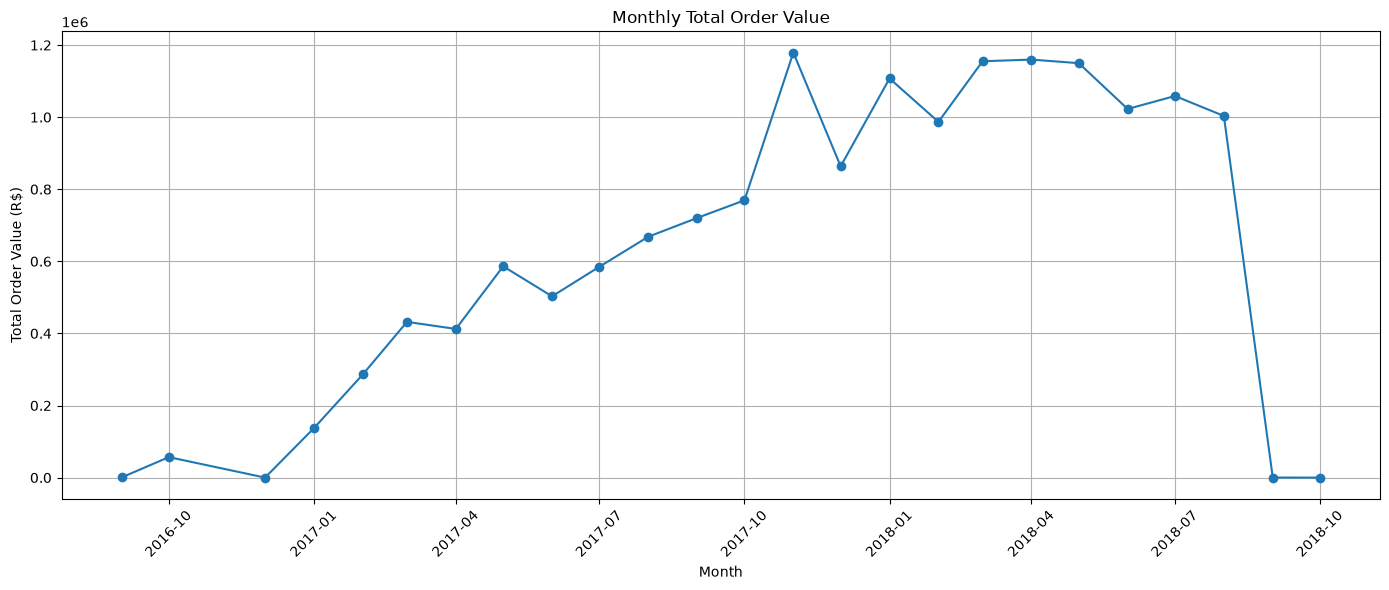

In [206]:
import matplotlib.pyplot as plt

monthly_sales_plot = monthly_sales.copy()

monthly_sales_plot["date"] = pd.to_datetime(
    monthly_sales_plot["purchase_year"].astype(str)
    + "-"
    + monthly_sales_plot["purchase_month"].astype(str)
    + "-01"
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales_plot["date"],
    monthly_sales_plot["total_order_value"],
    marker="o"
)

plt.title("Monthly Total Order Value")
plt.xlabel("Month")
plt.ylabel("Total Order Value (R$)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [207]:
monthly_sales["AOV"] = (
    monthly_sales["total_order_value"] /
    monthly_sales["orders"]
)

monthly_sales.nlargest(5, "AOV")

,purchase_year,purchase_month,orders,product_sales,total_order_value,AOV
1,2016,10,324,49507.66,56808.84,175.335926
6,2017,4,2404,359927.23,412422.24,171.556672
3,2017,1,800,120312.87,137188.49,171.485613
21,2018,7,6292,895507.22,1058728.03,168.265739
11,2017,9,4285,624401.69,720398.91,168.121099


In [208]:
monthly_sales.nsmallest(5, "AOV")

,purchase_year,purchase_month,orders,product_sales,total_order_value,AOV
24,2018,10,4,0.00,0.00,0.000000
23,2018,9,16,145.00,166.46,10.403750
2,2016,12,1,10.90,19.62,19.620000
0,2016,9,4,267.36,354.75,88.687500
9,2017,7,4026,498031.48,584971.62,145.298465


In [209]:
monthly_sales_filtered = monthly_sales[
    monthly_sales["orders"] >= 500
]

monthly_sales_filtered.nlargest(5, "AOV")

,purchase_year,purchase_month,orders,product_sales,total_order_value,AOV
6,2017,4,2404,359927.23,412422.24,171.556672
3,2017,1,800,120312.87,137188.49,171.485613
21,2018,7,6292,895507.22,1058728.03,168.265739
11,2017,9,4285,624401.69,720398.91,168.121099
19,2018,5,6873,996517.68,1149781.82,167.289658


In [210]:
monthly_sales_filtered.nsmallest(5, "AOV")

,purchase_year,purchase_month,orders,product_sales,total_order_value,AOV
9,2017,7,4026,498031.48,584971.62,145.298465
16,2018,2,6728,844178.71,986908.96,146.686825
14,2017,12,5673,743914.17,863547.23,152.220559
15,2018,1,7269,950030.36,1107301.89,152.332080
22,2018,8,6512,854686.33,1003308.47,154.070711


In [211]:
category_sales = (
    order_items_clean
    .merge(
        products_clean[
            ["product_id", "product_category_analysis"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_analysis")
    .agg(
        orders=("order_id", "nunique"),
        items_sold=("product_id", "count"),
        product_sales=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

category_sales["total_value"] = (
    category_sales["product_sales"] +
    category_sales["freight_value"]
)

category_sales.nlargest(10, "product_sales")

,product_category_analysis,orders,items_sold,product_sales,freight_value,total_value
44,health_beauty,8836,9670,1258681.34,182566.73,1441248.07
73,watches_gifts,5624,5991,1205005.68,100535.93,1305541.61
8,bed_bath_table,9417,11115,1036988.68,204693.04,1241681.72
68,sports_leisure,7720,8641,988048.97,168607.51,1156656.48
16,computers_accessories,6689,7827,911954.32,147318.08,1059272.40
40,furniture_decor,6449,8334,729762.49,172749.30,902511.79
21,cool_stuff,3632,3796,635290.85,84039.10,719329.95
50,housewares,5884,6964,632248.66,146149.11,778397.77
6,auto,3897,4235,592720.11,92664.21,685384.32
43,garden_tools,3518,4347,485256.46,98962.75,584219.21


In [212]:
category_sales["avg_item_price"] = (
    category_sales["product_sales"] /
    category_sales["items_sold"]
)

category_sales.nlargest(10, "avg_item_price")

,product_category_analysis,orders,items_sold,product_sales,freight_value,total_value,avg_item_price
15,computers,181,203,222963.13,9836.30,232799.43,1098.340542
67,small_appliances_home_oven_and_coffee,75,76,47445.71,2747.86,50193.57,624.285658
46,home_appliances_2,234,238,113317.74,10600.18,123917.92,476.124958
1,agro_industry_and_commerce,182,212,72530.47,5843.60,78374.07,342.124858
57,musical_instruments,628,680,191498.88,18638.49,210137.37,281.616000
66,small_appliances,630,679,190648.58,16020.25,206668.83,280.778468
63,portateis_cozinha_e_preparadores_de_alimentos,14,15,3968.53,309.76,4278.29,264.568667
35,fixed_telephony,217,264,59583.00,4637.81,64220.81,225.693182
20,construction_tools_safety,167,194,40544.52,3919.10,44463.62,208.992371
73,watches_gifts,5624,5991,1205005.68,100535.93,1305541.61,201.135984


In [213]:
category_sales_filtered = category_sales[
    category_sales["items_sold"] >= 500
]

category_sales_filtered.nlargest(10, "avg_item_price")

,product_category_analysis,orders,items_sold,product_sales,freight_value,total_value,avg_item_price
57,musical_instruments,628,680,191498.88,18638.49,210137.37,281.616000
66,small_appliances,630,679,190648.58,16020.25,206668.83,280.778468
73,watches_gifts,5624,5991,1205005.68,100535.93,1305541.61,201.135984
21,cool_stuff,3632,3796,635290.85,84039.10,719329.95,167.357969
58,office_furniture,1273,1691,273960.70,68571.95,342532.65,162.011059
18,construction_tools_construction,748,929,144677.59,20650.41,165328.00,155.734758
6,auto,3897,4235,592720.11,92664.21,685384.32,139.957523
17,consoles_games,1062,1137,157465.22,19828.02,177293.24,138.491838
49,home_construction,490,604,83088.12,13832.24,96920.36,137.563113
41,furniture_living_room,422,503,68916.56,17968.17,86884.73,137.011054


In [214]:
category_sales_filtered.nsmallest(10, "avg_item_price")

,product_category_analysis,orders,items_sold,product_sales,freight_value,total_value,avg_item_price
37,food,450,510,29393.41,7271.03,36664.44,57.634137
27,electronics,2550,2767,160246.74,46578.32,206825.06,57.913531
71,telephony,4199,4545,323667.53,71215.79,394883.32,71.213978
29,fashion_bags_accessories,1864,2031,152823.54,31450.00,184273.54,75.245465
9,books_general_interest,512,553,46856.88,9195.52,56052.40,84.732152
40,furniture_decor,6449,8334,729762.49,172749.30,902511.79,87.564494
50,housewares,5884,6964,632248.66,146149.11,778397.77,90.788148
69,stationery,2311,2517,230943.23,46798.48,277741.71,91.753369
8,bed_bath_table,9417,11115,1036988.68,204693.04,1241681.72,93.296327
45,home_appliances,764,771,80171.53,14818.90,94990.43,103.983826


In [215]:
total_product_sales = category_sales["product_sales"].sum()

category_sales["sales_share_pct"] = (
    category_sales["product_sales"] /
    total_product_sales * 100
)

category_sales.nlargest(10, "sales_share_pct")[
    [
        "product_category_analysis",
        "product_sales",
        "sales_share_pct"
    ]
]

,product_category_analysis,product_sales,sales_share_pct
44,health_beauty,1258681.34,9.260700
73,watches_gifts,1205005.68,8.865783
8,bed_bath_table,1036988.68,7.629605
68,sports_leisure,988048.97,7.269533
16,computers_accessories,911954.32,6.709669
40,furniture_decor,729762.49,5.369200
21,cool_stuff,635290.85,4.674128
50,housewares,632248.66,4.651745
6,auto,592720.11,4.360916
43,garden_tools,485256.46,3.570256


In [216]:
top_10_share = (
    category_sales
    .nlargest(10, "product_sales")["product_sales"]
    .sum()
    / total_product_sales * 100
)

top_10_share

np.float64(62.361534388956954)

In [217]:
state_sales = (
    orders_clean
    .dropna(subset=["total_order_value"])
    .groupby("customer_id")
    .agg(
        customer_unique_id=("customer_unique_id", "first"),
        total_order_value=("total_order_value", "first")
    )
    .reset_index()
    .merge(
        customers_clean[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
)

state_sales_summary = (
    state_sales
    .groupby("customer_state")
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("customer_id", "count"),
        total_order_value=("total_order_value", "sum")
    )
    .reset_index()
)

state_sales_summary.nlargest(10, "total_order_value")

,customer_state,customers,orders,total_order_value
25,SP,39981,41375,5921678.12
18,RJ,12303,12762,2129681.98
10,MG,11178,11544,1856161.49
22,RS,5249,5432,885826.76
17,PR,4840,4998,800935.44
4,BA,3257,3358,611506.67
23,SC,3513,3612,610213.60
6,DF,2062,2125,353229.44
8,GO,1942,2007,347706.93
7,ES,1956,2025,324801.91


In [218]:
state_sales_summary["AOV"] = (
    state_sales_summary["total_order_value"] /
    state_sales_summary["orders"]
)

state_sales_summary.nlargest(10, "AOV")

,customer_state,customers,orders,total_order_value,AOV
14,PB,516,532,140987.81,265.014680
0,AC,77,81,19669.70,242.835802
3,AP,67,68,16262.80,239.158824
1,AL,399,411,96229.40,234.134793
20,RO,235,247,57558.02,233.028421
13,PA,944,970,217647.11,224.378464
26,TO,272,279,61354.42,219.908315
16,PI,481,493,108132.28,219.335254
21,RR,45,46,10064.62,218.796087
24,SE,338,345,73032.32,211.687884


In [219]:
state_sales_filtered = state_sales_summary[
    state_sales_summary["orders"] >= 500
]

state_sales_filtered.nlargest(10, "AOV")

,customer_state,customers,orders,total_order_value,AOV
14,PB,516,532,140987.81,265.014680
13,PA,944,970,217647.11,224.378464
5,CE,1305,1327,275606.30,207.691258
12,MT,873,903,186168.96,206.167176
9,MA,719,740,151171.99,204.286473
15,PE,1605,1648,322237.69,195.532579
11,MS,688,709,135956.67,191.758350
4,BA,3257,3358,611506.67,182.104428
8,GO,1942,2007,347706.93,173.247100
23,SC,3513,3612,610213.60,168.940642


In [220]:
state_sales_filtered.nsmallest(10, "AOV")

,customer_state,customers,orders,total_order_value,AOV
25,SP,39981,41375,5921678.12,143.122130
17,PR,4840,4998,800935.44,160.251188
7,ES,1956,2025,324801.91,160.396005
10,MG,11178,11544,1856161.49,160.790150
22,RS,5249,5432,885826.76,163.075619
6,DF,2062,2125,353229.44,166.225619
18,RJ,12303,12762,2129681.98,166.876820
23,SC,3513,3612,610213.60,168.940642
8,GO,1942,2007,347706.93,173.247100
4,BA,3257,3358,611506.67,182.104428


In [221]:
customer_type = (
    customer_order_frequency
    .value_counts()
    .sort_index()
)

customer_type

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [222]:
one_time_customers = (customer_order_frequency == 1).sum()
repeat_customers = (customer_order_frequency > 1).sum()

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)
print(
    "Repeat customer rate:",
    round(repeat_customers / len(customer_order_frequency) * 100, 2),
    "%"
)

One-time customers: 93099
Repeat customers: 2997
Repeat customer rate: 3.12 %


In [223]:
repeat_order_share = (
    orders_clean["is_repeat_customer"].sum()
    / orders_clean["order_id"].nunique()
    * 100
)

print("Orders from repeat customers:", 
      orders_clean.loc[
          orders_clean["is_repeat_customer"], 
          "order_id"
      ].nunique())

print("Repeat-customer order share:",
      round(repeat_order_share, 2), "%")

Orders from repeat customers: 6342
Repeat-customer order share: 6.38 %


In [224]:
customer_type_summary = (
    orders_clean
    .groupby("is_repeat_customer")
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        total_order_value=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .reset_index()
)

customer_type_summary

,is_repeat_customer,customers,orders,total_order_value,average_order_value
0,False,93099,93099,14921510.75,161.434051
1,True,2997,6342,922042.49,147.881715


In [225]:
customer_type_summary["customer_type"] = (
    customer_type_summary["is_repeat_customer"]
    .map({
        False: "One-time",
        True: "Repeat"
    })
)

customer_type_summary[
    [
        "customer_type",
        "customers",
        "orders",
        "total_order_value",
        "average_order_value"
    ]
]

,customer_type,customers,orders,total_order_value,average_order_value
0,One-time,93099,93099,14921510.75,161.434051
1,Repeat,2997,6342,922042.49,147.881715


In [226]:
customer_value = (
    orders_clean
    .dropna(subset=["total_order_value"])
    .groupby("customer_unique_id")
    .agg(
        orders=("order_id", "nunique"),
        total_spend=("total_order_value", "sum")
    )
    .reset_index()
)

customer_value.head()

,customer_unique_id,orders,total_spend
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


In [227]:
customer_value.describe()

,orders,total_spend
count,95420.000000,95420.000000
mean,1.034018,166.040172
std,0.211234,228.320333
min,1.000000,9.590000
25%,1.000000,63.100000
50%,1.000000,107.940000
75%,1.000000,183.220000
max,16.000000,13664.080000


In [228]:
customer_value.nlargest(10, "total_spend")

,customer_unique_id,orders,total_spend
3799,0a0a92112bd4c708ca5fde585afaa872,1,13664.08
81388,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63
44139,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88
82230,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31
26015,459bef486812aa25204be022145caa62,1,6922.21
95131,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66
23947,4007669dec559734d6f53e029e360987,1,6081.54
34820,5d0a2980b292d049061542014e8960bf,1,4809.44
89056,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34
27242,48e1ac109decbb87765a3eade6854098,1,4681.78


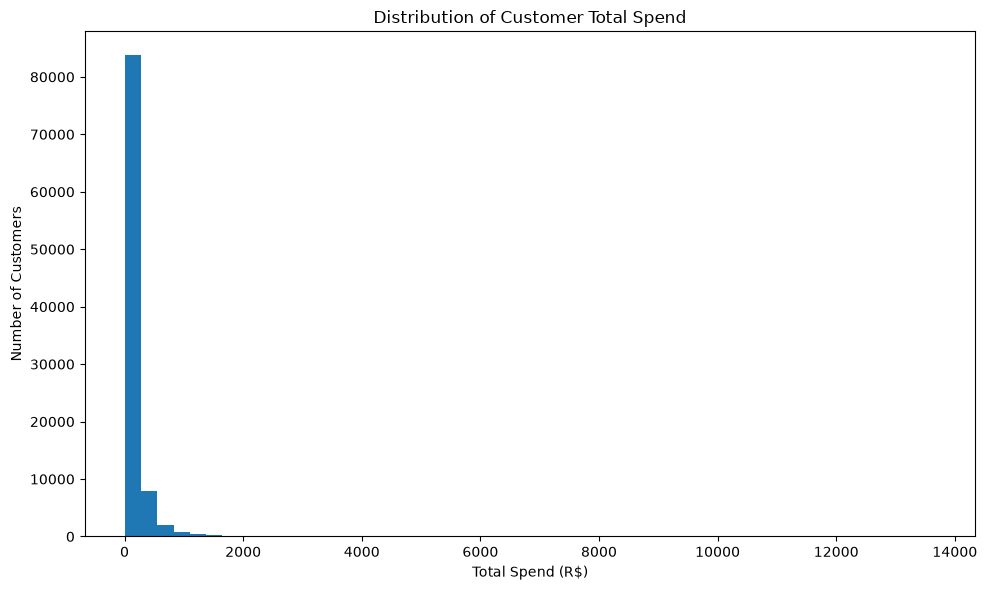

In [229]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    customer_value["total_spend"],
    bins=50
)

plt.title("Distribution of Customer Total Spend")
plt.xlabel("Total Spend (R$)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

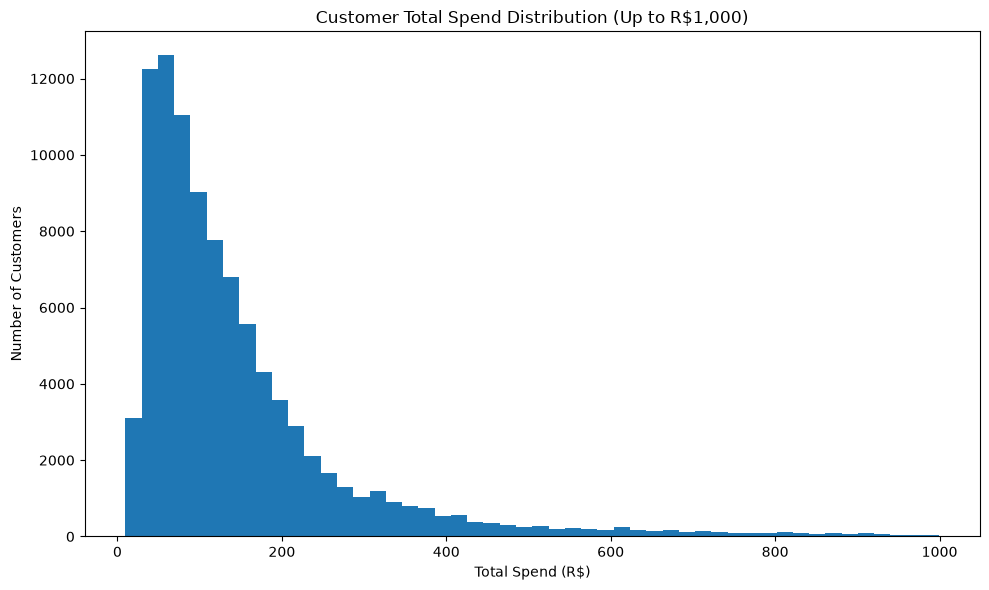

In [230]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_value.loc[
        customer_value["total_spend"] <= 1000,
        "total_spend"
    ],
    bins=50
)

plt.title("Customer Total Spend Distribution (Up to R$1,000)")
plt.xlabel("Total Spend (R$)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

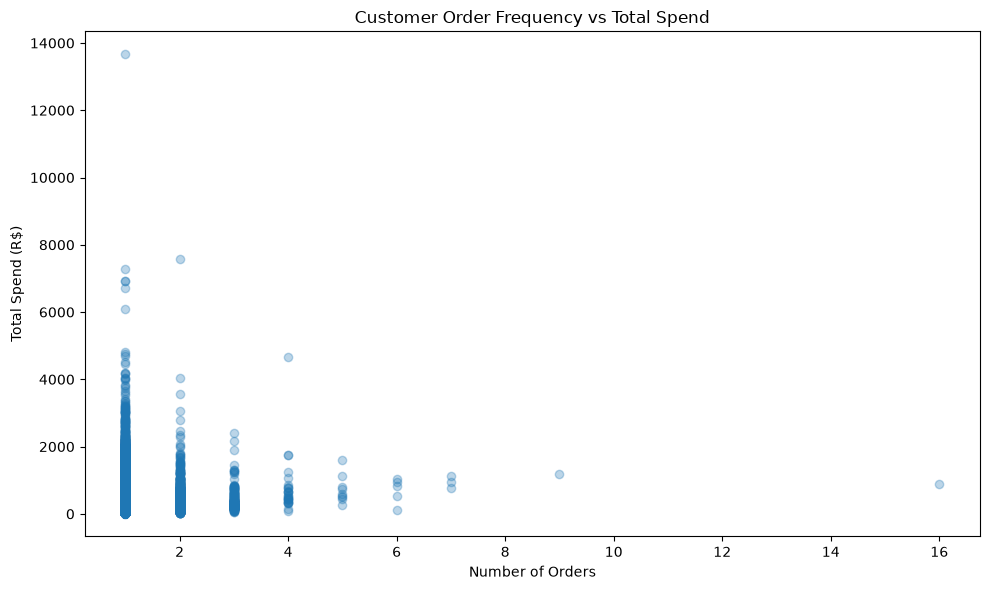

In [231]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_value["orders"],
    customer_value["total_spend"],
    alpha=0.3
)

plt.title("Customer Order Frequency vs Total Spend")
plt.xlabel("Number of Orders")
plt.ylabel("Total Spend (R$)")

plt.tight_layout()
plt.show()

In [232]:
customer_value[["orders", "total_spend"]].corr()

,orders,total_spend
orders,1.000000,0.122122
total_spend,0.122122,1.000000


In [233]:
review_distribution = (
    reviews_clean["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = [
    "review_score",
    "review_count"
]

review_distribution["percentage"] = (
    review_distribution["review_count"]
    / review_distribution["review_count"].sum()
    * 100
)

review_distribution

,review_score,review_count,percentage
0,1,11424,11.513344
1,2,3151,3.175643
2,3,8179,8.242965
3,4,19142,19.291704
4,5,57328,57.776344


In [234]:
average_review_score = reviews_clean["review_score"].mean()

print("Average Review Score:",
      round(average_review_score, 2))

Average Review Score: 4.09


In [235]:
order_reviews = (
    orders_clean[
        [
            "order_id",
            "delivery_days",
            "delivery_delay_days",
            "delivery_status"
        ]
    ]
    .merge(
        reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

order_reviews.shape

(99224, 5)

In [236]:
order_reviews.groupby("review_score")["delivery_days"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
review_score,,,
1,9389,21.338311,16.817002
2,2937,16.676632,13.268993
3,7950,14.272613,12.058819
4,18946,12.322824,10.803785
5,56949,10.694854,9.239525


In [237]:
order_reviews.groupby("delivery_status")["review_score"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
delivery_status,,,
Delayed,7697,2.565935,2.0
On Time / Early,88474,4.293826,5.0
Unknown,3053,1.909270,1.0


In [238]:
pd.crosstab(
    order_reviews["delivery_status"],
    order_reviews["review_score"],
    normalize="index"
) * 100

review_score,1,2,3,4,5
delivery_status,,,,,
Delayed,46.160842,7.873197,11.381058,12.381447,22.203456
On Time / Early,6.596288,2.634672,7.995569,20.337048,62.436422
Unknown,66.655748,7.009499,7.500819,6.419915,12.414019


In [239]:
order_reviews["delay_group"] = pd.cut(
    order_reviews["delivery_delay_days"],
    bins=[-np.inf, -10, 0, 5, 10, 20, np.inf],
    labels=[
        "More than 10 days early",
        "Early / On Time",
        "1–5 days late",
        "6–10 days late",
        "11–20 days late",
        "More than 20 days late"
    ]
)

In [240]:
order_reviews.groupby("delay_group", observed=True)["review_score"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
delay_group,,,
More than 10 days early,57097,4.322241,5.0
Early / On Time,31377,4.242120,5.0
1–5 days late,3582,3.460078,4.0
6–10 days late,1868,1.892398,1.0
11–20 days late,1391,1.665708,1.0
More than 20 days late,856,1.757009,1.0


In [241]:
from scipy.stats import mannwhitneyu

delayed_scores = order_reviews.loc[
    order_reviews["delivery_status"] == "Delayed",
    "review_score"
]

ontime_scores = order_reviews.loc[
    order_reviews["delivery_status"] == "On Time / Early",
    "review_score"
]

stat, p_value = mannwhitneyu(
    delayed_scores,
    ontime_scores,
    alternative="two-sided"
)

print("Mann–Whitney U statistic:", stat)
print("p-value:", p_value)

Mann–Whitney U statistic: 151961090.5
p-value: 0.0


In [242]:
order_category = (
    order_items_clean
    .merge(
        products_clean[
            ["product_id", "product_category_analysis"]
        ],
        on="product_id",
        how="left"
    )
    [["order_id", "product_category_analysis"]]
    .drop_duplicates()
)

order_category.shape

(99470, 2)

In [243]:
category_reviews = (
    order_category
    .merge(
        reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

category_reviews.shape

(99273, 3)

In [244]:
category_review_summary = (
    category_reviews
    .groupby("product_category_analysis")
    .agg(
        reviews=("review_score", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

In [245]:
category_review_filtered = category_review_summary[
    category_review_summary["reviews"] >= 100
]

In [246]:
category_review_filtered.nlargest(
    10,
    "average_review_score"
)

,product_category_analysis,reviews,average_review_score
9,books_general_interest,508,4.462598
11,books_technical,259,4.405405
38,food_drink,228,4.385965
54,luggage_accessories,1030,4.331068
37,food,445,4.276404
69,stationery,2302,4.244136
62,pet_shop,1703,4.238990
32,fashion_shoes,239,4.213389
22,costruction_tools_garden,196,4.198980
61,perfumery,3165,4.198420


In [247]:
category_review_filtered.nsmallest(
    10,
    "average_review_score"
)

,product_category_analysis,reviews,average_review_score
58,office_furniture,1268,3.617508
31,fashion_male_clothing,111,3.702703
5,audio,348,3.827586
20,construction_tools_safety,166,3.849398
48,home_confort,398,3.859296
35,fixed_telephony,215,3.902326
0,Unknown,1448,3.913674
34,fashion_underwear_beach,120,3.933333
8,bed_bath_table,9432,3.968617
49,home_construction,488,3.969262


In [248]:
seller_sales = (
    order_items_clean
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        items_sold=("product_id", "count"),
        product_sales=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

seller_sales["total_value"] = (
    seller_sales["product_sales"] +
    seller_sales["freight_value"]
)

seller_sales.nlargest(10, "product_sales")

,seller_id,orders,items_sold,product_sales,freight_value,total_value
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,20168.07,249640.70
1013,53243585a1d6dc2643021fd1853d8905,358,410,222776.05,13080.63,235856.68
881,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,35067.04,235539.96
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,10042.70,204084.73
1535,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,51612.55,239536.44
1560,7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,6322.18,182754.05
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,24955.75,185192.32
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,20902.85,162648.38
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,33892.14,172860.69
1824,955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70,25430.98,160602.68


In [249]:
total_seller_sales = seller_sales["product_sales"].sum()

seller_sales_sorted = seller_sales.sort_values(
    "product_sales",
    ascending=False
).reset_index(drop=True)

for n in [5, 10, 20, 50, 100]:
    share = (
        seller_sales_sorted.head(n)["product_sales"].sum()
        / total_seller_sales
        * 100
    )
    
    print(f"Top {n} sellers sales share: {share:.2f}%")

Top 5 sellers sales share: 7.61%
Top 10 sellers sales share: 13.15%
Top 20 sellers sales share: 21.09%
Top 50 sellers sales share: 32.89%
Top 100 sellers sales share: 45.06%


In [250]:
seller_reviews = (
    order_items_clean[
        ["order_id", "seller_id"]
    ]
    .drop_duplicates()
    .merge(
        reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

In [251]:
seller_review_summary = (
    seller_reviews
    .groupby("seller_id")
    .agg(
        reviews=("review_score", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

In [252]:
seller_review_filtered = seller_review_summary[
    seller_review_summary["reviews"] >= 50
]

In [253]:
seller_review_filtered.nlargest(
    10,
    "average_review_score"
)

,seller_id,reviews,average_review_score
2526,d13e50eaa47b4cbe9eb81465865d8cfc,67,4.820896
2624,d9bd94811c3338dceb4181f3dbc0c73e,54,4.796296
2575,d566c37fa119d5e66c4e9052e83ee4ea,64,4.687500
646,376a891762bbdecbc02b4b6adec3fdda,57,4.666667
322,1bb2bdb95f4841f1bba2c0d2cd83d3c9,81,4.641975
201,116ccb1a1604bc88e4d234a8c23f33de,61,4.639344
100,080199a181c46c657dc5aa235411be3b,78,4.615385
1120,5b925e1d006e9476d738aa200751b73b,66,4.606061
2073,ac3508719a1d8f5b7614b798f70af136,101,4.603960
2797,e882b2a25a10b9c057cc49695f222c19,59,4.593220


In [254]:
seller_review_filtered.nsmallest(
    10,
    "average_review_score"
)

,seller_id,reviews,average_review_score
333,1ca7077d890b907f89be8c954a02686a,114,2.333333
553,2eb70248d66e0e3ef83659f71b244378,199,2.693467
1029,54965bbe3e4f07ae045b90b0b8541f52,74,3.000000
2000,a49928bcdf77c55c6d6e05e09a9b4ca5,98,3.010204
1842,972d0f9cf61b499a4812cf0bfa3ad3c4,79,3.025316
491,2a1348e9addc1af5aaa619b1a3679d6b,51,3.117647
1175,602044f2c16190c2c6e45eb35c2e21cb,51,3.137255
2253,bbad7e518d7af88a0897397ffdca1979,68,3.161765
959,5058e8c1e82653974541e83690655b4a,62,3.241935
1622,8444e55c1f13cd5c179851e5ca5ebd00,99,3.262626


In [255]:
payment_summary = (
    payments_clean
    .groupby("payment_type")
    .agg(
        payment_records=("order_id", "count"),
        orders=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum")
    )
    .reset_index()
)

payment_summary

,payment_type,payment_records,orders,total_payment_value
0,boleto,19784,19784,2869361.27
1,credit_card,76795,76505,12542084.19
2,debit_card,1529,1528,217989.79
3,not_defined,3,3,0.00
4,voucher,5775,3866,379436.87


In [256]:
payment_summary["payment_record_share_pct"] = (
    payment_summary["payment_records"]
    / payment_summary["payment_records"].sum()
    * 100
)

payment_summary

,payment_type,payment_records,orders,total_payment_value,payment_record_share_pct
0,boleto,19784,19784,2869361.27,19.043952
1,credit_card,76795,76505,12542084.19,73.922376
2,debit_card,1529,1528,217989.79,1.471806
3,not_defined,3,3,0.00,0.002888
4,voucher,5775,3866,379436.87,5.558978


In [257]:
payment_summary["payment_value_share_pct"] = (
    payment_summary["total_payment_value"]
    / payment_summary["total_payment_value"].sum()
    * 100
)

payment_summary[
    [
        "payment_type",
        "orders",
        "total_payment_value",
        "payment_value_share_pct"
    ]
]

,payment_type,orders,total_payment_value,payment_value_share_pct
0,boleto,19784,2869361.27,17.923569
1,credit_card,76505,12542084.19,78.344584
2,debit_card,1528,217989.79,1.361681
3,not_defined,3,0.00,0.000000
4,voucher,3866,379436.87,2.370166


In [258]:
payment_summary["avg_payment_value"] = (
    payment_summary["total_payment_value"] /
    payment_summary["payment_records"]
)

payment_summary[
    [
        "payment_type",
        "payment_records",
        "total_payment_value",
        "avg_payment_value"
    ]
].sort_values(
    "avg_payment_value",
    ascending=False
)


,payment_type,payment_records,total_payment_value,avg_payment_value
1,credit_card,76795,12542084.19,163.319021
0,boleto,19784,2869361.27,145.034435
2,debit_card,1529,217989.79,142.570170
4,voucher,5775,379436.87,65.703354
3,not_defined,3,0.00,0.000000


In [259]:
installment_summary = (
    payments_clean
    .groupby("payment_installments")
    .agg(
        payment_records=("order_id", "count"),
        total_payment_value=("payment_value", "sum")
    )
    .reset_index()
    .sort_values("payment_installments")
)

installment_summary

,payment_installments,payment_records,total_payment_value
0,0,2,188.63
1,1,52546,5907233.36
2,2,12413,1579283.03
3,3,10461,1491103.80
4,4,7098,1163907.61
5,5,5239,961174.30
6,6,3920,822611.81
7,7,1626,305157.39
8,8,4268,1313423.34
9,9,644,131015.92


In [260]:
installment_summary["value_share_pct"] = (
    installment_summary["total_payment_value"]
    / installment_summary["total_payment_value"].sum()
    * 100
)

installment_summary

,payment_installments,payment_records,total_payment_value,value_share_pct
0,0,2,188.63,0.001178
1,1,52546,5907233.36,36.899747
2,2,12413,1579283.03,9.865049
3,3,10461,1491103.80,9.314234
4,4,7098,1163907.61,7.270391
5,5,5239,961174.30,6.004010
6,6,3920,822611.81,5.138474
7,7,1626,305157.39,1.906177
8,8,4268,1313423.34,8.204347
9,9,644,131015.92,0.818396


In [261]:
credit_installment_summary = (
    payments_clean[
        payments_clean["payment_type"] == "credit_card"
    ]
    .groupby("payment_installments")
    .agg(
        payment_records=("order_id", "count"),
        orders=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum")
    )
    .reset_index()
    .sort_values("payment_installments")
)

credit_installment_summary

,payment_installments,payment_records,orders,total_payment_value
0,0,2,2,188.63
1,1,25455,25407,2440445.43
2,2,12413,12389,1579283.03
3,3,10461,10443,1491103.80
4,4,7098,7088,1163907.61
5,5,5239,5234,961174.30
6,6,3920,3916,822611.81
7,7,1626,1623,305157.39
8,8,4268,4253,1313423.34
9,9,644,644,131015.92


In [262]:
credit_installment_summary["value_share_pct"] = (
    credit_installment_summary["total_payment_value"]
    / credit_installment_summary["total_payment_value"].sum()
    * 100
)

credit_installment_summary

,payment_installments,payment_records,orders,total_payment_value,value_share_pct
0,0,2,2,188.63,0.001504
1,1,25455,25407,2440445.43,19.458053
2,2,12413,12389,1579283.03,12.591871
3,3,10461,10443,1491103.80,11.888804
4,4,7098,7088,1163907.61,9.280018
5,5,5239,5234,961174.30,7.663593
6,6,3920,3916,822611.81,6.558813
7,7,1626,1623,305157.39,2.433068
8,8,4268,4253,1313423.34,10.472130
9,9,644,644,131015.92,1.044610


In [263]:
def installment_group(x):
    if x == 1:
        return "1 installment"
    elif x <= 3:
        return "2–3 installments"
    elif x <= 6:
        return "4–6 installments"
    elif x <= 12:
        return "7–12 installments"
    else:
        return "13+ installments"

credit_installment_summary["installment_group"] = (
    credit_installment_summary["payment_installments"]
    .apply(installment_group)
)

installment_group_summary = (
    credit_installment_summary
    .groupby("installment_group")
    .agg(
        payment_records=("payment_records", "sum"),
        orders=("orders", "sum"),
        total_payment_value=("total_payment_value", "sum")
    )
    .reset_index()
)

installment_group_summary["value_share_pct"] = (
    installment_group_summary["total_payment_value"]
    / installment_group_summary["total_payment_value"].sum()
    * 100
)

installment_group_summary

,installment_group,payment_records,orders,total_payment_value,value_share_pct
0,1 installment,25455,25407,2440445.43,19.458053
1,13+ installments,185,185,76538.91,0.610257
2,2–3 installments,22876,22834,3070575.46,24.482179
3,4–6 installments,16257,16238,2947693.72,23.502423
4,7–12 installments,12022,11991,4006830.67,31.947088


In [264]:
orders_clean.shape

(99441, 26)

In [265]:
orders_clean.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_month_name',
 'purchase_day',
 'purchase_day_of_week',
 'valid_delivery_sequence',
 'delivery_days',
 'estimated_delivery_days',
 'delivery_delay_days',
 'is_delayed',
 'delivery_status',
 'product_sales',
 'freight_value',
 'item_count',
 'total_order_value',
 'customer_unique_id',
 'is_repeat_customer',
 'customer_order_count']

In [266]:
customers_clean.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [267]:
delivery_state = orders_clean[
    [
        "order_id",
        "customer_id",
        "valid_delivery_sequence",
        "delivery_days",
        "delivery_status",
        "delivery_delay_days"
    ]
].merge(
    customers_clean[
        ["customer_id", "customer_state"]
    ],
    on="customer_id",
    how="left"
)

In [268]:
delivery_state.shape

(99441, 7)

In [269]:
delivery_state.columns.tolist()

['order_id',
 'customer_id',
 'valid_delivery_sequence',
 'delivery_days',
 'delivery_status',
 'delivery_delay_days',
 'customer_state']

In [270]:
state_delivery_summary = (
    delivery_state
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        valid_deliveries=("valid_delivery_sequence", "sum"),
        delayed_orders=("delivery_status", lambda x: (x == "Delayed").sum()),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean")
    )
    .reset_index()
)

state_delivery_summary["delayed_delivery_pct"] = (
    state_delivery_summary["delayed_orders"]
    / state_delivery_summary["valid_deliveries"]
    * 100
)

In [271]:
state_delivery_summary.sort_values(
    "delayed_delivery_pct",
    ascending=False
)

,customer_state,total_orders,valid_deliveries,delayed_orders,avg_delivery_days,avg_delay_days,delayed_delivery_pct
1,AL,413,397,95,24.543855,-8.032059,23.929471
9,MA,747,714,141,21.609402,-8.873883,19.747899
16,PI,495,473,76,19.506684,-10.564835,16.067653
5,CE,1336,1278,196,21.274425,-10.106068,15.336463
24,SE,350,334,51,21.548008,-9.310409,15.269461
4,BA,3380,3252,456,19.336804,-10.088194,14.022140
18,RJ,12852,12333,1664,15.321074,-11.048792,13.492257
26,TO,280,273,35,17.696470,-11.436912,12.820513
13,PA,975,945,117,23.783045,-13.379076,12.380952
7,ES,2033,1989,244,15.807431,-9.779926,12.267471


In [272]:
state_delivery_500 = (
    state_delivery_summary[
        state_delivery_summary["valid_deliveries"] >= 500
    ]
    .sort_values(
        "delayed_delivery_pct",
        ascending=False
    )
)

state_delivery_500

,customer_state,total_orders,valid_deliveries,delayed_orders,avg_delivery_days,avg_delay_days,delayed_delivery_pct
9,MA,747,714,141,21.609402,-8.873883,19.747899
5,CE,1336,1278,196,21.274425,-10.106068,15.336463
4,BA,3380,3252,456,19.336804,-10.088194,14.022140
18,RJ,12852,12333,1664,15.321074,-11.048792,13.492257
13,PA,975,945,117,23.783045,-13.379076,12.380952
7,ES,2033,1989,244,15.807431,-9.779926,12.267471
11,MS,715,699,81,15.645075,-10.349040,11.587983
14,PB,536,517,57,20.426768,-12.599502,11.025145
15,PE,1652,1592,172,18.450442,-12.600618,10.804020
23,SC,3637,3535,346,14.986152,-10.778831,9.787836


In [273]:
review_state = delivery_state.merge(
    reviews_clean[
        ["order_id", "review_score"]
    ],
    on="order_id",
    how="left"
)

In [274]:
state_delivery_review = (
    review_state
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        valid_deliveries=("valid_delivery_sequence", "sum"),
        delayed_orders=("delivery_status", lambda x: (x == "Delayed").sum()),
        avg_delivery_days=("delivery_days", "mean"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

state_delivery_review["delayed_delivery_pct"] = (
    state_delivery_review["delayed_orders"]
    / state_delivery_review["valid_deliveries"]
    * 100
)

In [275]:
state_delivery_review_500 = (
    state_delivery_review[
        state_delivery_review["valid_deliveries"] >= 500
    ]
    .sort_values(
        "delayed_delivery_pct",
        ascending=False
    )
)

state_delivery_review_500

,customer_state,total_orders,valid_deliveries,delayed_orders,avg_delivery_days,avg_review_score,delayed_delivery_pct
9,MA,747,718,141,21.557979,3.764075,19.637883
5,CE,1336,1281,197,21.275869,3.851016,15.378610
4,BA,3380,3269,460,19.357413,3.860888,14.071582
18,RJ,12852,12403,1674,15.330461,3.874971,13.496735
13,PA,975,951,117,23.786593,3.849174,12.302839
7,ES,2033,1998,245,15.816181,4.041667,12.262262
11,MS,715,710,82,15.655911,4.118785,11.549296
14,PB,536,518,57,20.403993,4.018832,11.003861
15,PE,1652,1603,172,18.420470,4.011543,10.729881
23,SC,3637,3549,348,15.006470,4.071764,9.805579


In [276]:
state_delivery_review_comparison = (
    review_state[
        review_state["delivery_status"].isin(["On Time/Early", "Delayed"])
    ]
    .groupby(["customer_state", "delivery_status"])
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

In [277]:
state_delivery_review_comparison

,customer_state,delivery_status,orders,avg_review_score
0,AC,Delayed,3,1.666667
1,AL,Delayed,95,2.311828
2,AM,Delayed,6,2.833333
3,AP,Delayed,3,4.666667
4,BA,Delayed,456,2.571749
5,CE,Delayed,196,2.194872
6,DF,Delayed,147,2.429530
7,ES,Delayed,244,2.736170
8,GO,Delayed,160,2.535032
9,MA,Delayed,141,2.401460


In [278]:
review_state["delivery_status"].value_counts(dropna=False)

delivery_status
On Time / Early    88954
Delayed             7862
Unknown             3176
Name: count, dtype: int64

In [279]:
state_delivery_review_comparison = (
    review_state[
        review_state["delivery_status"].isin(
            ["On Time / Early", "Delayed"]
        )
    ]
    .groupby(["customer_state", "delivery_status"])
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
    .sort_values(["customer_state", "delivery_status"])
)

state_delivery_review_comparison

,customer_state,delivery_status,orders,avg_review_score
0,AC,Delayed,3,1.666667
1,AC,On Time / Early,77,4.181818
2,AL,Delayed,95,2.311828
3,AL,On Time / Early,302,4.308197
4,AM,Delayed,6,2.833333
5,AM,On Time / Early,139,4.280576
6,AP,Delayed,3,4.666667
7,AP,On Time / Early,64,4.222222
8,BA,Delayed,456,2.571749
9,BA,On Time / Early,2796,4.146280


In [280]:
state_review_gap = (
    state_delivery_review_comparison
    .pivot(
        index="customer_state",
        columns="delivery_status",
        values=["orders", "avg_review_score"]
    )
    .reset_index()
)

state_review_gap.columns = [
    "_".join(col).strip("_")
    for col in state_review_gap.columns
]

state_review_gap["review_score_gap"] = (
    state_review_gap["avg_review_score_On Time / Early"]
    - state_review_gap["avg_review_score_Delayed"]
)

state_review_gap = state_review_gap.sort_values(
    "review_score_gap",
    ascending=False
)

state_review_gap

,customer_state,orders_Delayed,orders_On Time / Early,avg_review_score_Delayed,avg_review_score_On Time / Early,review_score_gap
0,AC,3.0,77.0,1.666667,4.181818,2.515152
21,RR,5.0,36.0,1.800000,4.194444,2.394444
19,RN,51.0,423.0,2.040000,4.399527,2.359527
24,SE,51.0,283.0,1.940000,4.254417,2.314417
18,RJ,1664.0,10669.0,2.130435,4.244192,2.113757
5,CE,196.0,1082.0,2.194872,4.251852,2.056980
13,PA,117.0,828.0,2.126126,4.151149,2.025023
15,PE,172.0,1420.0,2.279762,4.298381,2.018620
1,AL,95.0,302.0,2.311828,4.308197,1.996369
16,PI,76.0,397.0,2.440000,4.296954,1.856954


In [281]:
# Create one review score per order
review_order = (
    reviews_clean
    .groupby("order_id", as_index=False)
    .agg(
        avg_review_score=("review_score", "mean")
    )
)

# Merge with delivery and customer state information
state_delivery_review_clean = (
    delivery_state
    .merge(
        review_order,
        on="order_id",
        how="left"
    )
)

# State-level delivery and review summary
state_delivery_review_clean_summary = (
    state_delivery_review_clean
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        valid_deliveries=("valid_delivery_sequence", "sum"),
        delayed_orders=("delivery_status", lambda x: (x == "Delayed").sum()),
        avg_delivery_days=("delivery_days", "mean"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

state_delivery_review_clean_summary["delayed_delivery_pct"] = (
    state_delivery_review_clean_summary["delayed_orders"]
    / state_delivery_review_clean_summary["valid_deliveries"]
    * 100
)

state_delivery_review_clean_summary

,customer_state,total_orders,valid_deliveries,delayed_orders,avg_delivery_days,avg_review_score,delayed_delivery_pct
0,AC,81,80,3,21.035713,4.049383,3.750000
1,AL,413,397,95,24.543855,3.760976,23.929471
2,AM,148,145,6,26.425991,4.205479,4.137931
3,AP,68,67,3,27.185068,4.194030,4.477612
4,BA,3380,3252,456,19.336804,3.861078,14.022140
5,CE,1336,1278,196,21.274425,3.854449,15.336463
6,DF,2140,2077,147,12.978408,4.066964,7.077516
7,ES,2033,1989,244,15.807431,4.038385,12.267471
8,GO,2020,1951,160,15.628104,4.043348,8.200923
9,MA,747,714,141,21.609402,3.758086,19.747899


In [282]:
state_delivery_review_clean_comparison = (
    state_delivery_review_clean[
        state_delivery_review_clean["delivery_status"].isin(
            ["On Time / Early", "Delayed"]
        )
    ]
    .groupby(["customer_state", "delivery_status"])
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

state_delivery_review_clean_comparison = (
    state_delivery_review_clean_comparison
    .pivot(
        index="customer_state",
        columns="delivery_status",
        values=["orders", "avg_review_score"]
    )
    .reset_index()
)

state_delivery_review_clean_comparison.columns = [
    "_".join(col).strip("_")
    for col in state_delivery_review_clean_comparison.columns
]

state_delivery_review_clean_comparison["review_score_gap"] = (
    state_delivery_review_clean_comparison[
        "avg_review_score_On Time / Early"
    ]
    -
    state_delivery_review_clean_comparison[
        "avg_review_score_Delayed"
    ]
)

state_delivery_review_clean_comparison = (
    state_delivery_review_clean_comparison
    .sort_values("review_score_gap", ascending=False)
)

state_delivery_review_clean_comparison

,customer_state,orders_Delayed,orders_On Time / Early,avg_review_score_Delayed,avg_review_score_On Time / Early,review_score_gap
0,AC,3.0,77.0,1.666667,4.181818,2.515152
21,RR,5.0,36.0,1.800000,4.194444,2.394444
19,RN,51.0,423.0,2.040000,4.400238,2.360238
24,SE,51.0,283.0,1.940000,4.254417,2.314417
18,RJ,1664.0,10669.0,2.131547,4.245846,2.114299
5,CE,196.0,1082.0,2.195876,4.255102,2.059226
13,PA,117.0,828.0,2.126126,4.149817,2.023691
15,PE,172.0,1420.0,2.279762,4.297163,2.017401
1,AL,95.0,302.0,2.326087,4.317881,1.991794
16,PI,76.0,397.0,2.440000,4.295165,1.855165


In [283]:
seller_analysis = (
    orders_clean[
        [
            "order_id",
            "customer_id",
            "valid_delivery_sequence",
            "delivery_days",
            "delivery_status",
            "delivery_delay_days",
            "total_order_value"
        ]
    ]
    .merge(
        order_items_clean[
            ["order_id", "seller_id"]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        review_order,
        on="order_id",
        how="left"
    )
)

seller_summary = (
    seller_analysis
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        valid_deliveries=("valid_delivery_sequence", "sum"),
        delayed_orders=("delivery_status", lambda x: (x == "Delayed").sum()),
        total_sales=("total_order_value", "sum"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

seller_summary["delayed_delivery_pct"] = (
    seller_summary["delayed_orders"]
    / seller_summary["valid_deliveries"]
    * 100
)

seller_summary_100 = (
    seller_summary[
        seller_summary["orders"] >= 100
    ]
    .sort_values("total_sales", ascending=False)
)

seller_summary_100

,seller_id,orders,valid_deliveries,delayed_orders,total_sales,avg_delivery_days,avg_review_score,delayed_delivery_pct
1535,7c67e1448b00f6e969d365cea6b010ab,982,1354,130,507139.91,22.405139,3.341445,9.601182
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,1417,131,308207.01,12.061369,3.853107,9.244884
881,4a3ca9315b744ce9f8e9374361493884,1806,1947,214,301061.82,14.424871,3.803262,10.991269
368,1f50f920176fa81dab994f9023523100,1404,1926,182,290239.15,15.571831,3.987259,9.449637
1013,53243585a1d6dc2643021fd1853d8905,358,400,16,284902.94,13.374429,4.075980,4.000000
...,...,...,...,...,...,...,...,...
1544,7d76b645482be4a332374e8223836592,176,183,20,7356.38,13.264018,3.929730,10.928962
3046,fc906263ca5083d09dce42fe02247800,114,117,0,6938.88,9.348500,4.369748,0.000000
2650,db4350fd57ae30082dec7acbaacc17f9,137,145,6,6673.02,10.869059,4.124138,4.137931
2199,b76dba6c951ab00dc4edf0a1aa88037e,159,167,5,5463.30,10.246473,4.149701,2.994012


In [284]:
seller_sales = (
    order_items_clean
    .assign(
        item_sales=lambda x: x["price"] + x["freight_value"]
    )
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        total_sales=("item_sales", "sum"),
        item_count=("order_id", "count")
    )
    .reset_index()
)

seller_sales.head()

,seller_id,orders,total_sales,item_count
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2748.06,3
1,001cca7ae9ae17fb1caed9dfb1094831,200,33934.17,239
2,001e6ad469a905060d959994f1b41e4f,1,267.94,1
3,002100f778ceb8431b7a1020ff7ab48f,51,2028.16,55
4,003554e2dce176b5555353e4f3555ac8,1,139.38,1


In [285]:
seller_order_analysis = (
    order_items_clean[
        ["order_id", "seller_id"]
    ]
    .drop_duplicates()
    .merge(
        orders_clean[
            [
                "order_id",
                "valid_delivery_sequence",
                "delivery_days",
                "delivery_status"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        review_order,
        on="order_id",
        how="left"
    )
)

seller_performance = (
    seller_order_analysis
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        valid_deliveries=("valid_delivery_sequence", "sum"),
        delayed_orders=(
            "delivery_status",
            lambda x: (x == "Delayed").sum()
        ),
        avg_delivery_days=("delivery_days", "mean"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

seller_performance["delayed_delivery_pct"] = (
    seller_performance["delayed_orders"]
    / seller_performance["valid_deliveries"]
    * 100
)

In [286]:
seller_final = (
    seller_sales
    .merge(
        seller_performance,
        on="seller_id",
        how="left",
        suffixes=("_sales", "_performance")
    )
)

seller_final_100 = (
    seller_final[
        seller_final["orders_sales"] >= 100
    ]
    .sort_values("total_sales", ascending=False)
)

seller_final_100

,seller_id,orders_sales,total_sales,item_count,orders_performance,valid_deliveries,delayed_orders,avg_delivery_days,avg_review_score,delayed_delivery_pct
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,249640.70,1156,1132,1124,130,15.062424,4.133452,11.565836
1535,7c67e1448b00f6e969d365cea6b010ab,982,239536.44,1364,982,972,98,22.355824,3.486168,10.082305
1013,53243585a1d6dc2643021fd1853d8905,358,235856.68,410,358,348,15,13.432183,4.132022,4.310345
881,4a3ca9315b744ce9f8e9374361493884,1806,235539.96,1987,1806,1770,195,14.495364,3.827731,11.016949
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,204084.73,586,585,578,59,13.354636,4.339071,10.207612
...,...,...,...,...,...,...,...,...,...,...
712,3c7c4a49ec3c6550809089c6a2ca9370,141,5858.30,160,141,139,11,9.574327,3.659574,7.913669
795,42b729f859728f5079499127a9c2ef37,104,5434.07,132,104,101,8,7.886670,4.466019,7.920792
2650,db4350fd57ae30082dec7acbaacc17f9,137,5421.64,146,137,136,5,10.788565,4.139706,3.676471
2199,b76dba6c951ab00dc4edf0a1aa88037e,159,4881.88,169,159,157,5,10.381203,4.178344,3.184713


In [287]:
seller_high_sales_delay = (
    seller_final_100
    .sort_values(
        ["total_sales", "delayed_delivery_pct"],
        ascending=[False, False]
    )
)

seller_high_sales_delay[
    [
        "seller_id",
        "orders_sales",
        "total_sales",
        "delayed_orders",
        "delayed_delivery_pct",
        "avg_review_score"
    ]
].head(20)

,seller_id,orders_sales,total_sales,delayed_orders,delayed_delivery_pct,avg_review_score
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,249640.70,130,11.565836,4.133452
1535,7c67e1448b00f6e969d365cea6b010ab,982,239536.44,98,10.082305,3.486168
1013,53243585a1d6dc2643021fd1853d8905,358,235856.68,15,4.310345,4.132022
881,4a3ca9315b744ce9f8e9374361493884,1806,235539.96,195,11.016949,3.827731
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,204084.73,59,10.207612,4.339071
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,185192.32,100,7.633588,4.173547
1560,7e93a43ef30c4f03f38b393420bc753a,336,182754.05,18,5.642633,4.214925
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,172860.69,92,10.121012,3.992282
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,162648.38,68,5.938865,4.243701
1824,955fee9216a65b617aa5c0531780ce60,1287,160602.68,98,7.783956,4.157400


In [288]:
seller_low_review = (
    seller_final_100
    .sort_values("avg_review_score", ascending=True)
)

seller_low_review[
    [
        "seller_id",
        "orders_sales",
        "total_sales",
        "delayed_delivery_pct",
        "avg_delivery_days",
        "avg_review_score"
    ]
].head(20)

,seller_id,orders_sales,total_sales,delayed_delivery_pct,avg_delivery_days,avg_review_score
333,1ca7077d890b907f89be8c954a02686a,115,15001.43,22.222222,15.536054,2.333333
554,2eb70248d66e0e3ef83659f71b244378,202,45860.10,13.903743,18.013339,2.694444
1385,710e3548e02bc1d2831dfc4f1b5b14d4,136,27855.07,4.651163,14.627574,3.362963
1669,88460e8ebdecbfecb5f9601833981930,248,36543.10,19.672131,17.903158,3.423077
290,18a349e75d307f4b4cc646a691ed4216,121,10909.56,6.422018,11.154516,3.441667
2139,b2479f944e1b90cf8a5de1bbfde284d6,103,6992.22,13.861386,15.400405,3.450980
1535,7c67e1448b00f6e969d365cea6b010ab,982,239536.44,10.082305,22.355824,3.486168
1371,7040e82f899a04d1b434b795a43b4617,212,12955.98,9.615385,10.512130,3.600000
410,229c3efbfb0ea2058de4ccdfbc3d784a,121,18106.57,1.694915,10.759132,3.625000
1680,897060da8b9a21f655304d50fd935913,317,29887.47,11.842105,14.947159,3.625796


In [289]:
seller_high_delay = (
    seller_final_100
    .sort_values("delayed_delivery_pct", ascending=False)
)

seller_high_delay[
    [
        "seller_id",
        "orders_sales",
        "total_sales",
        "delayed_orders",
        "delayed_delivery_pct",
        "avg_review_score"
    ]
].head(20)

,seller_id,orders_sales,total_sales,delayed_orders,delayed_delivery_pct,avg_review_score
81,06a2c3af7b3aee5d69171b0e14f0ee87,392,48550.24,90,23.376623,3.989691
333,1ca7077d890b907f89be8c954a02686a,115,15001.43,24,22.222222,2.333333
1669,88460e8ebdecbfecb5f9601833981930,248,36543.10,48,19.672131,3.423077
2766,e5a3438891c0bfdb9394643f95273d8e,224,11112.62,40,18.518519,3.927928
2497,cd68562d3f44870c08922d380acae552,125,20777.19,22,18.032787,3.943548
1590,8160255418d5aaa7dbdc9f4c64ebda44,385,54871.50,63,16.578947,3.934383
527,2c9e548be18521d1c43cde1c582c6de8,126,8603.05,20,16.129032,4.112903
2678,dd7ddc04e1b6c2c614352b383efe2d36,122,12072.00,19,15.833333,3.851240
2994,f7ba60f8c3f99e7ee4042fdef03b70c4,219,72736.01,34,15.596330,4.205479
804,431af27f296bc6519d890aa5a05fdb11,117,15250.85,18,15.517241,3.775862


In [290]:
seller_low_review[
    [
        "seller_id",
        "orders_sales",
        "total_sales",
        "delayed_orders",
        "delayed_delivery_pct",
        "avg_delivery_days",
        "avg_review_score"
    ]
].head(20)

,seller_id,orders_sales,total_sales,delayed_orders,delayed_delivery_pct,avg_delivery_days,avg_review_score
333,1ca7077d890b907f89be8c954a02686a,115,15001.43,24,22.222222,15.536054,2.333333
554,2eb70248d66e0e3ef83659f71b244378,202,45860.10,26,13.903743,18.013339,2.694444
1385,710e3548e02bc1d2831dfc4f1b5b14d4,136,27855.07,6,4.651163,14.627574,3.362963
1669,88460e8ebdecbfecb5f9601833981930,248,36543.10,48,19.672131,17.903158,3.423077
290,18a349e75d307f4b4cc646a691ed4216,121,10909.56,7,6.422018,11.154516,3.441667
2139,b2479f944e1b90cf8a5de1bbfde284d6,103,6992.22,14,13.861386,15.400405,3.450980
1535,7c67e1448b00f6e969d365cea6b010ab,982,239536.44,98,10.082305,22.355824,3.486168
1371,7040e82f899a04d1b434b795a43b4617,212,12955.98,20,9.615385,10.512130,3.600000
410,229c3efbfb0ea2058de4ccdfbc3d784a,121,18106.57,2,1.694915,10.759132,3.625000
1680,897060da8b9a21f655304d50fd935913,317,29887.47,36,11.842105,14.947159,3.625796


In [291]:
seller_high_sales_low_review = (
    seller_final_100
    .sort_values(
        ["total_sales", "avg_review_score"],
        ascending=[False, True]
    )
)

seller_high_sales_low_review[
    [
        "seller_id",
        "orders_sales",
        "total_sales",
        "delayed_delivery_pct",
        "avg_delivery_days",
        "avg_review_score"
    ]
].head(20)

,seller_id,orders_sales,total_sales,delayed_delivery_pct,avg_delivery_days,avg_review_score
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,249640.70,11.565836,15.062424,4.133452
1535,7c67e1448b00f6e969d365cea6b010ab,982,239536.44,10.082305,22.355824,3.486168
1013,53243585a1d6dc2643021fd1853d8905,358,235856.68,4.310345,13.432183,4.132022
881,4a3ca9315b744ce9f8e9374361493884,1806,235539.96,11.016949,14.495364,3.827731
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,204084.73,10.207612,13.354636,4.339071
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,185192.32,7.633588,11.190604,4.173547
1560,7e93a43ef30c4f03f38b393420bc753a,336,182754.05,5.642633,11.314593,4.214925
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,172860.69,10.121012,12.396770,3.992282
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,162648.38,5.938865,11.200218,4.243701
1824,955fee9216a65b617aa5c0531780ce60,1287,160602.68,7.783956,10.771451,4.157400


In [292]:
category_satisfaction = (
    order_items_clean[
        ["order_id", "product_id"]
    ]
    .merge(
        products_clean[
            ["product_id", "product_category_analysis"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        review_order,
        on="order_id",
        how="left"
    )
)

category_satisfaction_summary = (
    category_satisfaction
    .groupby("product_category_analysis")
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

category_satisfaction_summary = (
    category_satisfaction_summary[
        category_satisfaction_summary["orders"] >= 100
    ]
    .sort_values("avg_review_score", ascending=True)
)

category_satisfaction_summary

,product_category_analysis,orders,avg_review_score
58,office_furniture,1273,3.488968
31,fashion_male_clothing,112,3.641221
35,fixed_telephony,217,3.681992
5,audio,350,3.831944
48,home_confort,397,3.833333
0,Unknown,1451,3.839836
20,construction_tools_safety,167,3.844560
8,bed_bath_table,9417,3.898334
41,furniture_living_room,422,3.901606
40,furniture_decor,6449,3.907333


In [293]:
category_order = (
    order_items_clean[
        ["order_id", "product_id"]
    ]
    .merge(
        products_clean[
            ["product_id", "product_category_analysis"]
        ],
        on="product_id",
        how="left"
    )
    .drop_duplicates(
        ["order_id", "product_category_analysis"]
    )
)

category_satisfaction_clean = (
    category_order
    .merge(
        review_order,
        on="order_id",
        how="left"
    )
)

category_satisfaction_clean_summary = (
    category_satisfaction_clean
    .groupby("product_category_analysis")
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

category_satisfaction_clean_summary = (
    category_satisfaction_clean_summary[
        category_satisfaction_clean_summary["orders"] >= 100
    ]
    .sort_values("avg_review_score", ascending=True)
)

category_satisfaction_clean_summary

,product_category_analysis,orders,avg_review_score
58,office_furniture,1273,3.616390
31,fashion_male_clothing,112,3.702703
5,audio,350,3.834294
20,construction_tools_safety,167,3.849398
48,home_confort,397,3.863291
35,fixed_telephony,217,3.901869
0,Unknown,1451,3.912787
34,fashion_underwear_beach,121,3.933333
49,home_construction,490,3.967146
8,bed_bath_table,9417,3.970740


In [294]:
category_satisfaction_clean_with_low = (
    category_satisfaction_clean
    .groupby("product_category_analysis")
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("avg_review_score", "mean"),
        low_rating_pct=(
            "avg_review_score",
            lambda x: (x <= 2).mean() * 100
        )
    )
    .reset_index()
)

category_satisfaction_clean_with_low = (
    category_satisfaction_clean_with_low[
        category_satisfaction_clean_with_low["orders"] >= 100
    ]
    .sort_values("low_rating_pct", ascending=False)
)

category_satisfaction_clean_with_low


,product_category_analysis,orders,avg_review_score,low_rating_pct
31,fashion_male_clothing,112,3.702703,25.892857
58,office_furniture,1273,3.616390,22.466614
5,audio,350,3.834294,21.714286
20,construction_tools_safety,167,3.849398,20.359281
0,Unknown,1451,3.912787,19.779462
48,home_confort,397,3.863291,19.143577
35,fixed_telephony,217,3.901869,18.433180
34,fashion_underwear_beach,121,3.933333,18.181818
49,home_construction,490,3.967146,17.551020
40,furniture_decor,6449,4.009691,16.498682
